Import libraries

In [44]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [45]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns; sns.set()
import shap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor, AdaBoostRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.inspection import PartialDependenceDisplay
from skopt import BayesSearchCV
from skopt.space import Integer, Real, Categorical
from skopt.plots import plot_convergence, plot_objective, plot_evaluations
from skopt.callbacks import CheckpointSaver

Import dataset

In [47]:
url = "2023_Data_BiomassGasification_NED.xlsx"
Data = pd.read_excel(url, sheet_name='Normalized Data')
Data.head()

,feed_particle_size,feed_LHV,C,H,N,S,O,feed_ash,feed_moisture,feed_VM,...,other_bed,alumina,Y-alumina,calcium oxide,dolomite,olivine,silica,sand,lab,pilot
0,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
1,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
2,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
3,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1
4,0.0681,0.236607,0.420376,0.458096,0.127396,0.042204,0.604911,0.467066,0.125441,0.196338,...,0,0,0,0,0,1,0,0,0,1


Data splitting (70% training, 30% testing)

In [48]:
X = pd.read_excel('Treated_predictor.xlsx')
Y = pd.read_excel('Clean_target.xlsx') 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.7, random_state=42)

In [49]:
X_train

,Particle size (mm),LHV (MJ/kg wb),C (%daf),H ($daf),O (%daf),N (%daf),S (%daf),Ash (%db),Moisture (%wb),Temperature (°C),...,Agent_air,Agent_air/steam,Agent_oxygen,Agent_steam,Agent_steam/oxygen,Reactor_fixed bed,Reactor_fluidised bed,Bed_alumina,Bed_olivine,Bed_silica
158,0.071382,0.446921,0.444371,0.128462,0.008745,0.019712,0.511072,0.132239,0.000000,0.776583,...,0,0,0,1,0,1,0,0,0,1
109,0.157101,0.446564,0.435694,0.054824,0.004742,0.003308,0.521938,0.016199,0.129361,0.584245,...,1,0,0,0,0,1,0,0,0,1
17,0.014090,0.950962,0.762596,0.254243,0.000000,0.000000,0.000000,0.029265,0.005880,0.791310,...,1,0,0,0,0,0,1,0,1,0
237,0.053524,0.347666,0.352362,0.132700,0.032626,0.166872,0.550188,0.139111,0.120933,0.922290,...,1,0,0,0,0,1,0,0,0,1
24,0.074102,0.890780,0.693531,0.235334,0.016314,0.011870,0.077304,0.043120,0.013720,0.847533,...,1,0,0,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.049953,0.251060,0.409089,0.116441,0.246256,0.088000,0.412549,1.000000,0.136221,0.825142,...,1,0,0,0,0,0,1,0,0,1
106,0.157101,0.415916,0.418824,0.055869,0.006823,0.000000,0.539280,0.032638,0.131321,0.582290,...,1,0,0,0,0,1,0,0,0,1
270,0.138386,0.342448,0.417045,0.139390,0.018163,0.000000,0.535031,0.389675,0.245002,1.000000,...,1,0,0,0,0,1,0,0,0,1
348,1.000000,0.418011,0.421657,0.134261,0.005382,0.001364,0.537109,0.057155,0.000000,0.907517,...,1,0,0,0,0,0,1,0,0,1


In [50]:
X_test.describe()

,Particle size (mm),LHV (MJ/kg wb),C (%daf),H ($daf),O (%daf),N (%daf),S (%daf),Ash (%db),Moisture (%wb),Temperature (°C),...,Agent_air,Agent_air/steam,Agent_oxygen,Agent_steam,Agent_steam/oxygen,Reactor_fixed bed,Reactor_fluidised bed,Bed_alumina,Bed_olivine,Bed_silica
count,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,...,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000,123.000000
mean,0.296611,0.443216,0.456328,0.137990,0.049971,0.038612,0.456045,0.231961,0.162011,0.819888,...,0.626016,0.170732,0.040650,0.146341,0.008130,0.186992,0.796748,0.097561,0.097561,0.788618
std,0.397639,0.207301,0.123921,0.065959,0.077997,0.064112,0.165430,0.324440,0.154050,0.107698,...,0.485838,0.377813,0.198287,0.354894,0.090167,0.391500,0.404064,0.297934,0.297934,0.409959
min,0.005284,0.236607,0.132694,0.044707,0.000000,0.000000,0.000000,0.006197,0.000000,0.536647,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.049953,0.325354,0.405004,0.116441,0.005382,0.000000,0.412549,0.022401,0.100549,0.757155,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
50%,0.071382,0.398067,0.423502,0.132700,0.017490,0.003946,0.505938,0.049640,0.152881,0.786296,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
75%,0.333178,0.440301,0.460429,0.154158,0.042956,0.065131,0.544911,0.378790,0.183065,0.915874,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,0.838926,0.448381,0.297309,0.293178,0.818084,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [51]:
Y_train

,N2 (% db),H2 (% db),CO (% db),CO2 (% db),CH4 (% db),C2Hn (% db),LHV (MJ/Nm3),Tar (g/Nm3),Gas yield (Nm3/kg wb)
158,0.00,46.54,14.65,32.61,2.870,3.33,9.878903,31.250,1.280000
109,59.70,10.00,20.60,7.90,1.800,NaN,4.300000,60.000,1.810000
17,46.40,28.20,21.10,1.50,2.300,0.50,6.800000,0.000,5.823529
237,51.15,8.23,13.55,20.37,1.840,1.12,3.320000,6.852,1.470000
24,61.00,9.60,4.50,10.90,8.600,5.40,7.900000,32.000,3.508861
...,...,...,...,...,...,...,...,...,...
71,63.30,9.70,8.20,13.90,2.100,1.40,2.900000,3.000,1.579450
106,55.00,11.10,20.30,11.10,2.500,NaN,4.600000,39.320,2.050000
270,66.54,5.78,12.27,14.55,0.608,0.24,2.530000,NaN,1.888889
348,45.44,20.95,23.50,9.92,0.190,0.00,5.740000,NaN,NaN


In [52]:
Y_test.describe()

,N2 (% db),H2 (% db),CO (% db),CO2 (% db),CH4 (% db),C2Hn (% db),LHV (MJ/Nm3),Tar (g/Nm3),Gas yield (Nm3/kg wb)
count,123.000000,123.000000,121.000000,121.000000,121.000000,98.000000,123.000000,59.000000,93.000000
mean,41.903794,20.259875,17.687520,14.501931,4.131888,1.448148,6.539945,20.012140,2.078459
std,24.266172,14.800860,8.196559,6.258525,3.123970,1.577516,3.077283,23.079385,1.234097
min,0.000000,3.200000,2.200000,0.900000,0.040000,0.000000,2.500000,0.000000,0.695310
25%,35.685000,9.650000,11.627215,11.000000,2.000000,0.072500,4.165000,3.650000,1.340114
50%,51.750000,15.830000,17.500000,14.180000,3.083559,1.150309,5.710000,11.800000,1.660000
75%,59.950000,24.700000,21.300000,17.060223,6.475615,2.100000,8.732500,27.901538,2.230000
max,68.000000,60.000000,40.500000,34.730000,13.500000,9.500000,13.450000,99.000000,6.000000


In [53]:
target_variable = Y.columns.to_list()
 
# Training data
XY_temp = X.copy() # create dataframe with all inputs and considered target
XY_temp[target_variable] = Y.copy() # add target
XY_temp = XY_temp.dropna() # drop all rows with missing values for model training

# Create temporary data sets for model training and testing
x_RF_temp = XY_temp.drop(target_variable, axis=1) 
y_RF_temp = XY_temp[target_variable]

# Create and fit model
model_RF_temp = RandomForestRegressor(random_state = 42)
model_RF_temp.fit(x_RF_temp, y_RF_temp)

# Make predictions and NaNs with predictions 
imputer_predictions = pd.DataFrame(model_RF_temp.predict(X_train))
imputer_predictions.columns = target_variable
#target_array= Y_train.to_numpy().flatten() # extract target array with NaNs
Y_train_pretreated = Y_train.copy().set_index(imputer_predictions.index)
Y_train_pretreated[Y_train_pretreated.isna()] = imputer_predictions

#Normalize data into [0,1]
#for index, row in Y_train_pretreated.iterrows():
#    for columns in Y_train_pretreated.columns:
#        norm = (row[columns] - Y_train_pretreated[columns].min()) / (Y_train_pretreated[columns].max() - Y_train_pretreated[columns].min())
#        Y_train_pretreated.at[index, columns] = norm
        
Y_train_pretreated

,N2 (% db),H2 (% db),CO (% db),CO2 (% db),CH4 (% db),C2Hn (% db),LHV (MJ/Nm3),Tar (g/Nm3),Gas yield (Nm3/kg wb)
0,0.00,46.54,14.65,32.61,2.870,3.330000,9.878903,31.250000,1.280000
1,59.70,10.00,20.60,7.90,1.800,1.656055,4.300000,60.000000,1.810000
2,46.40,28.20,21.10,1.50,2.300,0.500000,6.800000,0.000000,5.823529
3,51.15,8.23,13.55,20.37,1.840,1.120000,3.320000,6.852000,1.470000
4,61.00,9.60,4.50,10.90,8.600,5.400000,7.900000,32.000000,3.508861
...,...,...,...,...,...,...,...,...,...
280,63.30,9.70,8.20,13.90,2.100,1.400000,2.900000,3.000000,1.579450
281,55.00,11.10,20.30,11.10,2.500,1.024891,4.600000,39.320000,2.050000
282,66.54,5.78,12.27,14.55,0.608,0.240000,2.530000,5.476933,1.888889
283,45.44,20.95,23.50,9.92,0.190,0.000000,5.740000,12.521020,2.437769


In [54]:
Y_train_pretreated.describe()

,N2 (% db),H2 (% db),CO (% db),CO2 (% db),CH4 (% db),C2Hn (% db),LHV (MJ/Nm3),Tar (g/Nm3),Gas yield (Nm3/kg wb)
count,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000,285.000000
mean,38.140184,21.076957,19.359080,15.083084,4.809070,1.740369,7.394916,34.964990,1.905542
std,25.292239,15.001742,9.253025,6.541575,3.516833,1.520298,3.344427,42.377388,0.946788
min,0.000000,3.100000,2.300000,1.200000,0.050000,0.000000,1.300000,0.000000,0.494640
25%,1.000000,9.600000,12.750000,10.880000,2.100000,0.300000,4.599834,10.154840,1.312765
50%,49.260000,17.500000,18.000000,14.100000,4.000000,1.420000,6.300000,21.526316,1.874040
75%,57.739549,28.500000,23.500000,17.750000,7.500000,2.700000,11.109060,45.213910,2.214309
max,74.900000,71.500000,50.000000,38.250000,16.000000,7.000000,15.595450,364.000000,6.187500


Hyperparameter tuning using Bayesian optimization

In [120]:
#Define model
GBR = GradientBoostingRegressor(alpha=0.1)
XGB = XGBRegressor(objective='reg:squarederror')
ADA = AdaBoostRegressor()

def hyperparameter_tuning(model, X, Y, output):
  if model == GBR:
    #Define search spaces of every hyperparameter tuned in GBR
    search_spaces = {
        'n_estimators': (50, 500),
        'learning_rate': (1e-3, 1.0, 'log-uniform'),
        'max_depth': (1, 20),
        'min_samples_split': (2, 20),
        'min_samples_leaf': (1, 20),
        'subsample': (0.1, 1.0, 'uniform'),
        'max_features': (0.1, 1.0, 'uniform')
    }
    
    model_name = 'GBR'

  elif model == XGB:
    search_spaces = {
      'n_estimators': (50, 1000),
      'learning_rate': (0.01, 1.0, 'log-uniform'),
      'max_depth': (1, 10),
      'min_child_weight': (1, 10),
      'subsample': (0.5, 1.0, 'uniform'),
      'colsample_bytree': (0.5, 1.0, 'uniform'),
      'gamma': (0, 5),
      'reg_alpha': (1e-5, 1.0, 'log-uniform'),
      'reg_lambda': (1e-5, 1.0, 'log-uniform')
    }
    
    model_name = 'XGB'
    
  elif model == ADA:   
    search_spaces = {
      'n_estimators': (50,1000),
      'learning_rate': (0.01, 1.0, 'log-uniform'),
      'loss': ('linear', 'square', 'exponential'),
    }
    
    model_name = 'ADA'


  #Create optimize
  opt = BayesSearchCV(
      estimator=model,
      search_spaces=search_spaces,
      cv=5,
      n_iter=32,
      scoring='r2',
      n_jobs=-1,
      random_state=42
  )

  # Fit training data with optimizer
  opt.fit(X, Y[output])

  #Show optimization results
  print('Hyperparameter tuning of ', model_name,' model')
  print('Best parameters: ', opt.best_params_)
  print('Best score: ', opt.best_score_)
  print('--------------------------------------')

  return opt

In [121]:
#Get hyperparameters for GBR model
GBR_H2 = hyperparameter_tuning(GBR, X_train, Y_train_pretreated, output='H2 (% db)')

Hyperparameter tuning of  GBR  model
Best parameters:  OrderedDict([('learning_rate', 0.18779657096784486), ('max_depth', 20), ('max_features', 0.18087060417665268), ('min_samples_leaf', 4), ('min_samples_split', 13), ('n_estimators', 309), ('subsample', 0.6557911065396123)])
Best score:  0.9124241862060648
--------------------------------------


In [122]:
GBR_CO2 = hyperparameter_tuning(GBR, X_train, Y_train_pretreated, output='CO2 (% db)')

Hyperparameter tuning of  GBR  model
Best parameters:  OrderedDict([('learning_rate', 0.11937944237947451), ('max_depth', 20), ('max_features', 0.1), ('min_samples_leaf', 1), ('min_samples_split', 18), ('n_estimators', 500), ('subsample', 0.8149789840982836)])
Best score:  0.7554448073013527
--------------------------------------


In [123]:
GBR_CO = hyperparameter_tuning(GBR, X_train, Y_train_pretreated, output='CO (% db)')

Hyperparameter tuning of  GBR  model
Best parameters:  OrderedDict([('learning_rate', 0.07281827677637132), ('max_depth', 20), ('max_features', 0.1), ('min_samples_leaf', 6), ('min_samples_split', 12), ('n_estimators', 171), ('subsample', 0.9216556661877218)])
Best score:  0.8141051534838579
--------------------------------------


In [124]:
GBR_Tar = hyperparameter_tuning(GBR, X_train, Y_train_pretreated, output='Tar (g/Nm3)')

Hyperparameter tuning of  GBR  model
Best parameters:  OrderedDict([('learning_rate', 0.02382981516791142), ('max_depth', 20), ('max_features', 0.6014165883787167), ('min_samples_leaf', 9), ('min_samples_split', 20), ('n_estimators', 500), ('subsample', 1.0)])
Best score:  0.8270778642901384
--------------------------------------


In [60]:
#Get hyperparameters for XGB model
XGB_H2 = hyperparameter_tuning(XGB, X_train, Y_train_pretreated, output='H2 (% db)')

Hyperparameter tuning of  XGB  model
Best parameters:  OrderedDict([('colsample_bytree', 1.0), ('gamma', 4), ('learning_rate', 0.4601913629296267), ('max_depth', 4), ('min_child_weight', 7), ('n_estimators', 240), ('reg_alpha', 1e-05), ('reg_lambda', 0.00016628755342203006), ('subsample', 0.835135275422709)])
Best score:  0.9093871998511773
--------------------------------------


In [61]:
XGB_CO2 = hyperparameter_tuning(XGB, X_train, Y_train_pretreated, output='CO2 (% db)')

Hyperparameter tuning of  XGB  model
Best parameters:  OrderedDict([('colsample_bytree', 1.0), ('gamma', 0), ('learning_rate', 0.06885014512027246), ('max_depth', 7), ('min_child_weight', 6), ('n_estimators', 222), ('reg_alpha', 1.0), ('reg_lambda', 0.06114382415656487), ('subsample', 0.7639301677846564)])
Best score:  0.7546926870820977
--------------------------------------


In [62]:
XGB_CO = hyperparameter_tuning(XGB, X_train, Y_train_pretreated, output='CO (% db)')

Hyperparameter tuning of  XGB  model
Best parameters:  OrderedDict([('colsample_bytree', 0.617963026629376), ('gamma', 2), ('learning_rate', 0.0610043700814691), ('max_depth', 4), ('min_child_weight', 9), ('n_estimators', 912), ('reg_alpha', 7.648992840958424e-05), ('reg_lambda', 1.3296652540959836e-05), ('subsample', 0.6077782181130195)])
Best score:  0.8094512504460166
--------------------------------------


In [63]:
XGB_Tar = hyperparameter_tuning(XGB, X_train, Y_train_pretreated, output='Tar (g/Nm3)')

Hyperparameter tuning of  XGB  model
Best parameters:  OrderedDict([('colsample_bytree', 0.6978173130081514), ('gamma', 4), ('learning_rate', 0.020005871985558577), ('max_depth', 3), ('min_child_weight', 10), ('n_estimators', 777), ('reg_alpha', 0.00015449685239934808), ('reg_lambda', 0.005021984360469223), ('subsample', 0.9779633380743717)])
Best score:  0.8090381352546947
--------------------------------------


In [64]:
#Get hyperparameters for ADA model
ADA_H2 = hyperparameter_tuning(ADA, X_train, Y_train_pretreated, output='H2 (% db)')

Hyperparameter tuning of  ADA  model
Best parameters:  OrderedDict([('learning_rate', 1.0), ('loss', 'square'), ('n_estimators', 427)])
Best score:  0.8472413519316253
--------------------------------------


In [65]:
ADA_CO2 = hyperparameter_tuning(ADA, X_train, Y_train_pretreated, output='CO2 (% db)')

Hyperparameter tuning of  ADA  model
Best parameters:  OrderedDict([('learning_rate', 0.3016152430872132), ('loss', 'square'), ('n_estimators', 54)])
Best score:  0.6996716625707597
--------------------------------------


In [66]:
ADA_CO = hyperparameter_tuning(ADA, X_train, Y_train_pretreated, output='CO (% db)')

Hyperparameter tuning of  ADA  model
Best parameters:  OrderedDict([('learning_rate', 0.06296345733100522), ('loss', 'square'), ('n_estimators', 1000)])
Best score:  0.6732491336994247
--------------------------------------


In [67]:
ADA_Tar = hyperparameter_tuning(ADA, X_train, Y_train_pretreated, output='Tar (g/Nm3)')

Hyperparameter tuning of  ADA  model
Best parameters:  OrderedDict([('learning_rate', 0.0839760190305906), ('loss', 'exponential'), ('n_estimators', 138)])
Best score:  0.6816563785877665
--------------------------------------


Model training

In [68]:
#Create function for model configuration
def predict_evaluate(model_H2, model_CO2, model_CO, model_Tar, X, Y):
    #Model evaluation with training dataset
    Y_predict_H2 = model_H2.predict(X)
    Y_predict_CO2 = model_CO2.predict(X)
    Y_predict_CO = model_CO.predict(X)
    Y_predict_Tar = model_Tar.predict(X)

    Predict = pd.DataFrame({'H2 (% db)': Y_predict_H2.flatten(),
                            'CO2 (% db)': Y_predict_CO2.flatten(),
                            'CO (% db)': Y_predict_CO.flatten(),
                            'Tar (g/Nm3)': Y_predict_Tar.flatten()})

    for i in ['H2 (% db)', 'CO2 (% db)', 'CO (% db)', 'Tar (g/Nm3)']:
        R2 = r2_score(Y[i], Predict[i])
        MSE = mean_squared_error(Y[i], Predict[i])
        print(f'Evaluation score of {i} model;')
        print(f'R2 score: {R2:.2f}')
        print(f'MSE: {MSE:.2f}')
        print('-----------------------------')
        
    return Predict

In [129]:
#model_GBR configuration using the tuned hyperparameter
model_GBR_H2 = GradientBoostingRegressor(**GBR_H2.best_params_)

model_GBR_CO2 = GradientBoostingRegressor(**GBR_CO2.best_params_)

model_GBR_CO = GradientBoostingRegressor(**GBR_CO.best_params_)

model_GBR_Tar = GradientBoostingRegressor(**GBR_Tar.best_params_)

#FIt model_GBR with training data
model_GBR_H2.fit(X_train, Y_train_pretreated['H2 (% db)'])
model_GBR_CO2.fit(X_train, Y_train_pretreated['CO2 (% db)'])
model_GBR_CO.fit(X_train, Y_train_pretreated['CO (% db)'])
model_GBR_Tar.fit(X_train, Y_train_pretreated['Tar (g/Nm3)'])

#Predict and evaluate model_GBR performance
Predict_train = predict_evaluate(model_GBR_H2, model_GBR_CO2, model_GBR_CO, model_GBR_Tar, X_train, Y_train_pretreated)

Evaluation score of H2 (% db) model;
R2 score: 0.99
MSE: 2.80
-----------------------------
Evaluation score of CO2 (% db) model;
R2 score: 0.97
MSE: 1.21
-----------------------------
Evaluation score of CO (% db) model;
R2 score: 0.94
MSE: 5.02
-----------------------------
Evaluation score of Tar (g/Nm3) model;
R2 score: 0.98
MSE: 35.53
-----------------------------


Model testing

In [133]:
Y_test_pretreated = Y_test.dropna(axis=0)
X_test_pretreated = X_test.loc[Y_test_pretreated.index]

#Normalize data into [0,1]
#for index, row in Y_test_pretreated.iterrows():
#    for columns in Y_test_pretreated.columns:
#        norm = (row[columns] - Y_test_pretreated[columns].min()) / (Y_test_pretreated[columns].max() - Y_test_pretreated[columns].min())
#        Y_test_pretreated.at[index, columns] = norm

Predict_test = predict_evaluate(model_GBR_H2, model_GBR_CO2, model_GBR_CO, model_GBR_Tar, X_test_pretreated, Y_test_pretreated)

Evaluation score of H2 (% db) model;
R2 score: 0.95
MSE: 14.21
-----------------------------
Evaluation score of CO2 (% db) model;
R2 score: 0.96
MSE: 2.30
-----------------------------
Evaluation score of CO (% db) model;
R2 score: 0.92
MSE: 5.74
-----------------------------
Evaluation score of Tar (g/Nm3) model;
R2 score: 0.73
MSE: 165.20
-----------------------------


Plot of Actual vs Prediction with distribution

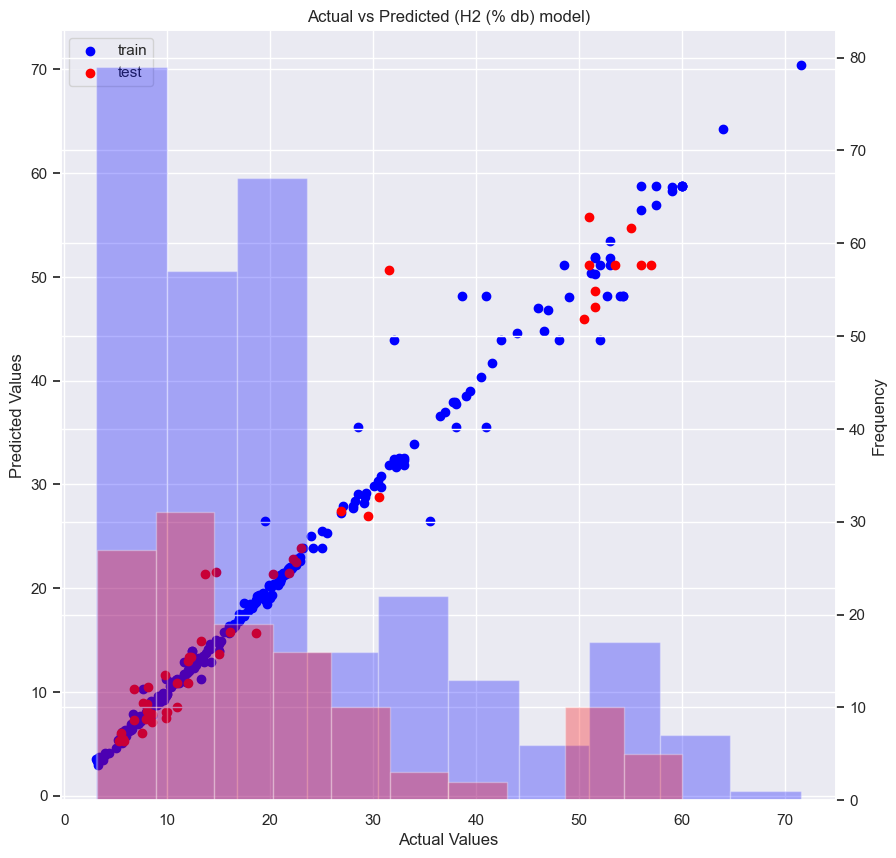

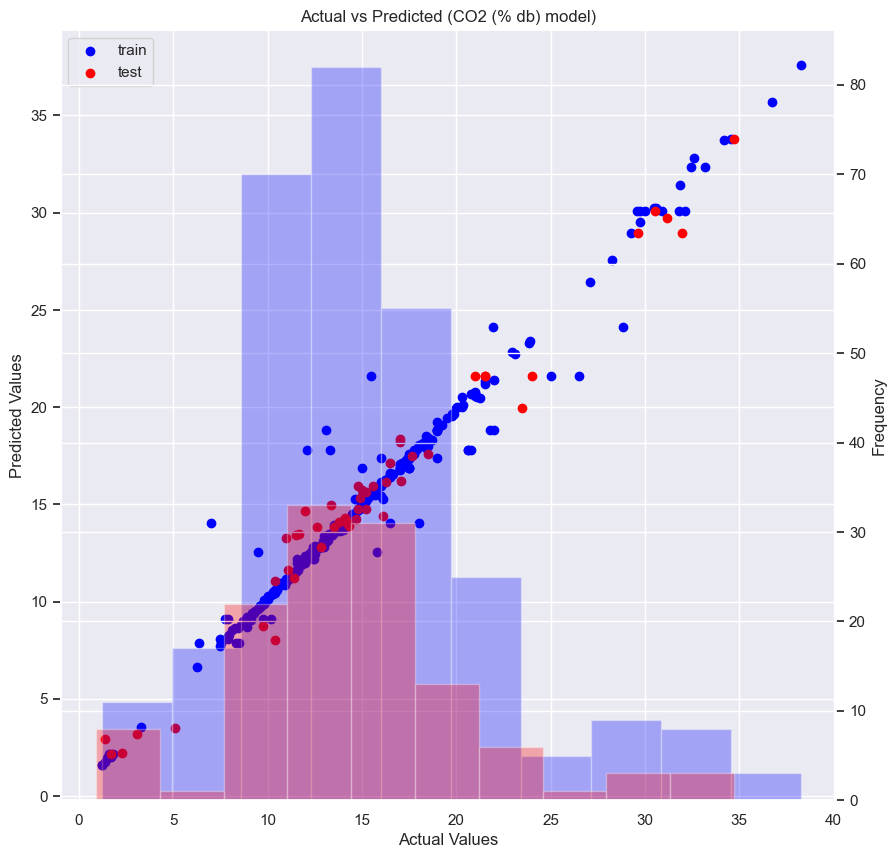

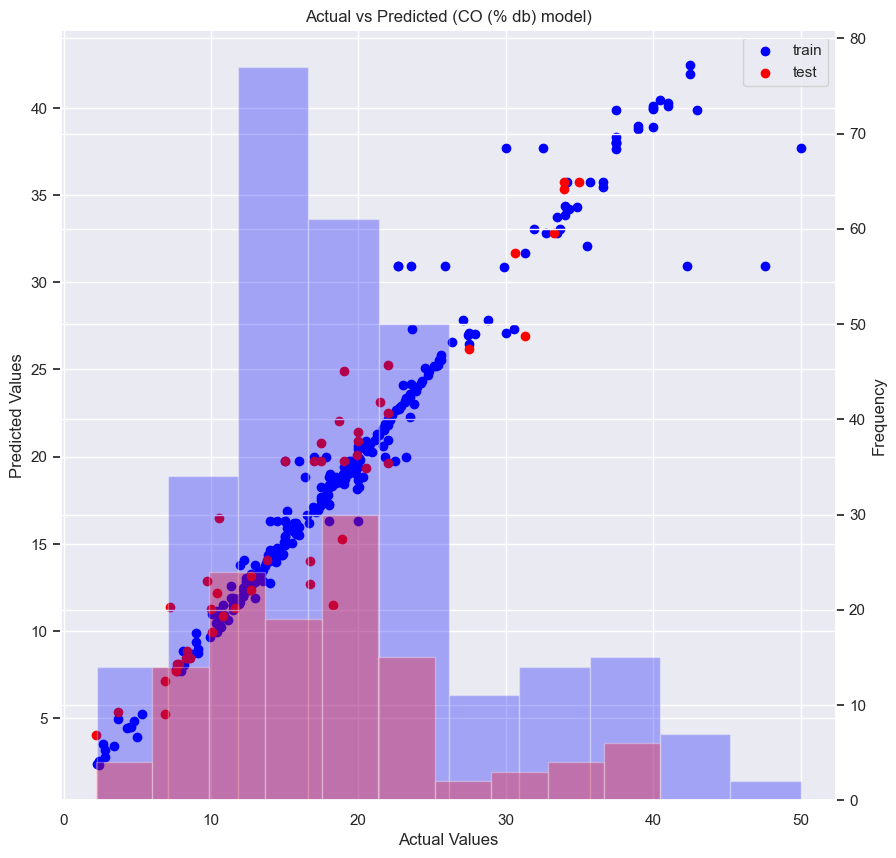

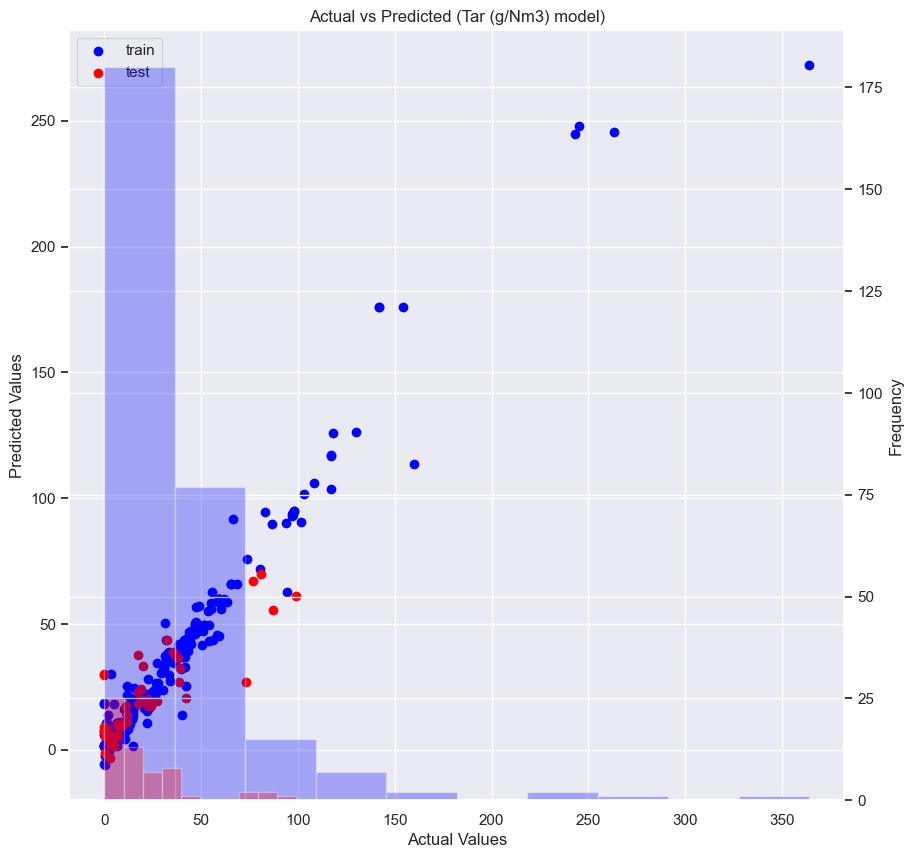

In [71]:
for model in ['H2 (% db)', 'CO2 (% db)', 'CO (% db)', 'Tar (g/Nm3)']:
  fig, ax1 = plt.subplots(figsize=(10,10))
  ax1.scatter(Y_train_pretreated[model], Predict_train[model], color='blue', label='train')
  ax1.scatter(Y_test_pretreated[model], Predict_test[model], color='red', label='test')
  #ax1.plot([0,0], [1,1], 'r--', label='Ideal fit')
  ax1.set_xlabel('Actual Values')
  ax1.set_ylabel('Predicted Values')
  ax1.legend()

  ax2 = ax1.twinx()
  ax2.hist(Y_train_pretreated[model], bins=10, alpha=0.3, color='blue')
  ax2.hist(Y_test[model], bins=10, alpha=0.3, color='red')
  ax2.set_ylabel('Frequency')
  
  plt.title(f'Actual vs Predicted ({model} model)')
  plt.show()

XGB

In [72]:
#model configuration using the tuned hyperparameter
model_XGB_H2 = XGBRegressor(**XGB_H2.best_params_)

model_XGB_CO2 = XGBRegressor(**XGB_CO2.best_params_)

model_XGB_CO = XGBRegressor(**XGB_CO.best_params_)

model_XGB_Tar = XGBRegressor(**XGB_Tar.best_params_)

#FIt model_XGB with training data
model_XGB_H2.fit(X_train, Y_train_pretreated['H2 (% db)'])
model_XGB_CO2.fit(X_train, Y_train_pretreated['CO2 (% db)'])
model_XGB_CO.fit(X_train, Y_train_pretreated['CO (% db)'])
model_XGB_Tar.fit(X_train, Y_train_pretreated['Tar (g/Nm3)'])

#Predict and evaluate model_XGB performance
Predict_train = predict_evaluate(model_XGB_H2, model_XGB_CO2, model_XGB_CO, model_XGB_Tar, X_train, Y_train_pretreated)

Evaluation score of H2 (% db) model;
R2 score: 0.99
MSE: 3.34
-----------------------------
Evaluation score of CO2 (% db) model;
R2 score: 0.97
MSE: 1.37
-----------------------------
Evaluation score of CO (% db) model;
R2 score: 0.95
MSE: 4.18
-----------------------------
Evaluation score of Tar (g/Nm3) model;
R2 score: 0.97
MSE: 57.90
-----------------------------


In [73]:
Y_test_pretreated = Y_test.dropna(axis=0)
X_test_pretreated = X_test.loc[Y_test_pretreated.index]

#Normalize data into [0,1]
#for index, row in Y_test_pretreated.iterrows():
#    for columns in Y_test_pretreated.columns:
#        norm = (row[columns] - Y_test_pretreated[columns].min()) / (Y_test_pretreated[columns].max() - Y_test_pretreated[columns].min())
#        Y_test_pretreated.at[index, columns] = norm

Predict_test = predict_evaluate(model_XGB_H2, model_XGB_CO2, model_XGB_CO, model_XGB_Tar, X_test_pretreated, Y_test_pretreated)

Evaluation score of H2 (% db) model;
R2 score: 0.95
MSE: 13.59
-----------------------------
Evaluation score of CO2 (% db) model;
R2 score: 0.94
MSE: 3.00
-----------------------------
Evaluation score of CO (% db) model;
R2 score: 0.91
MSE: 6.47
-----------------------------
Evaluation score of Tar (g/Nm3) model;
R2 score: 0.77
MSE: 138.58
-----------------------------


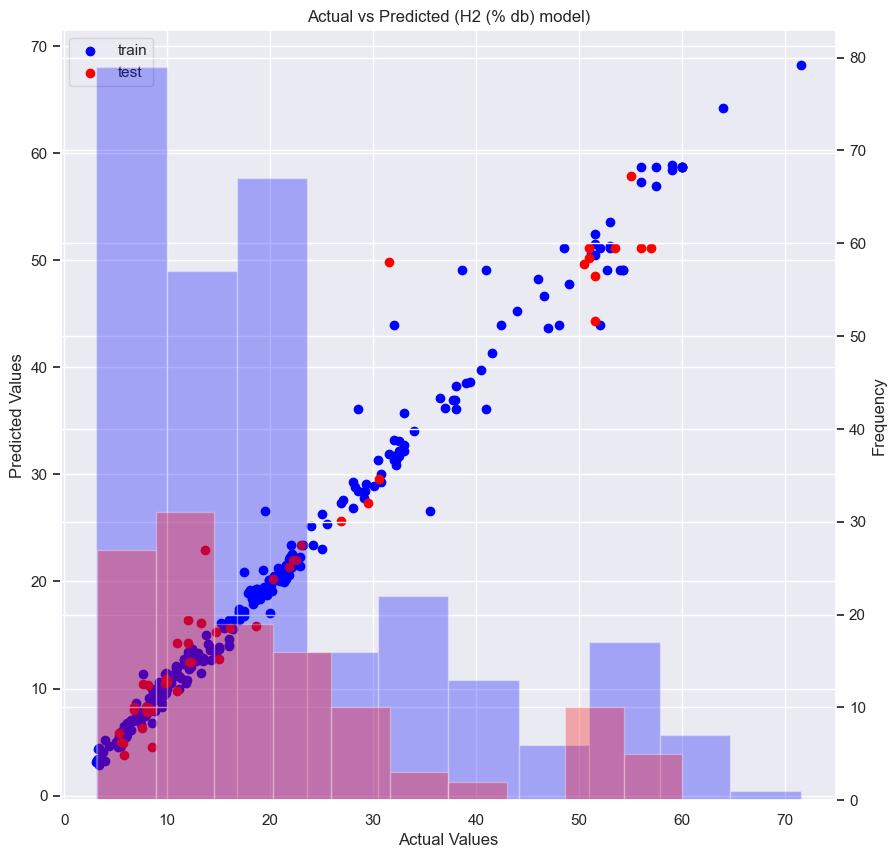

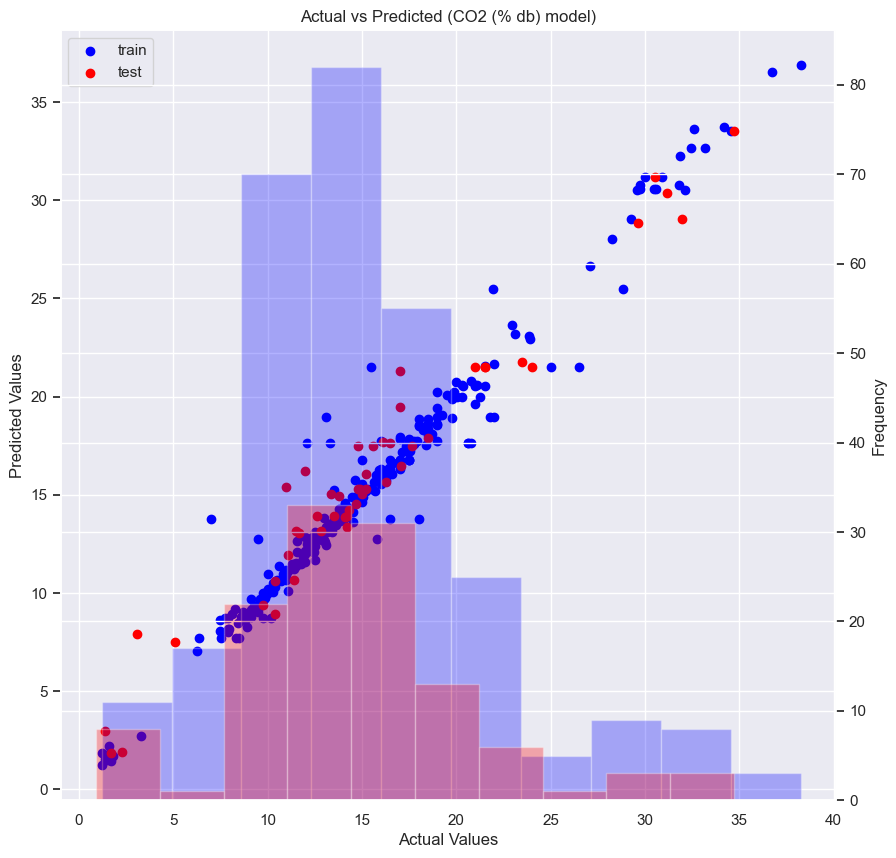

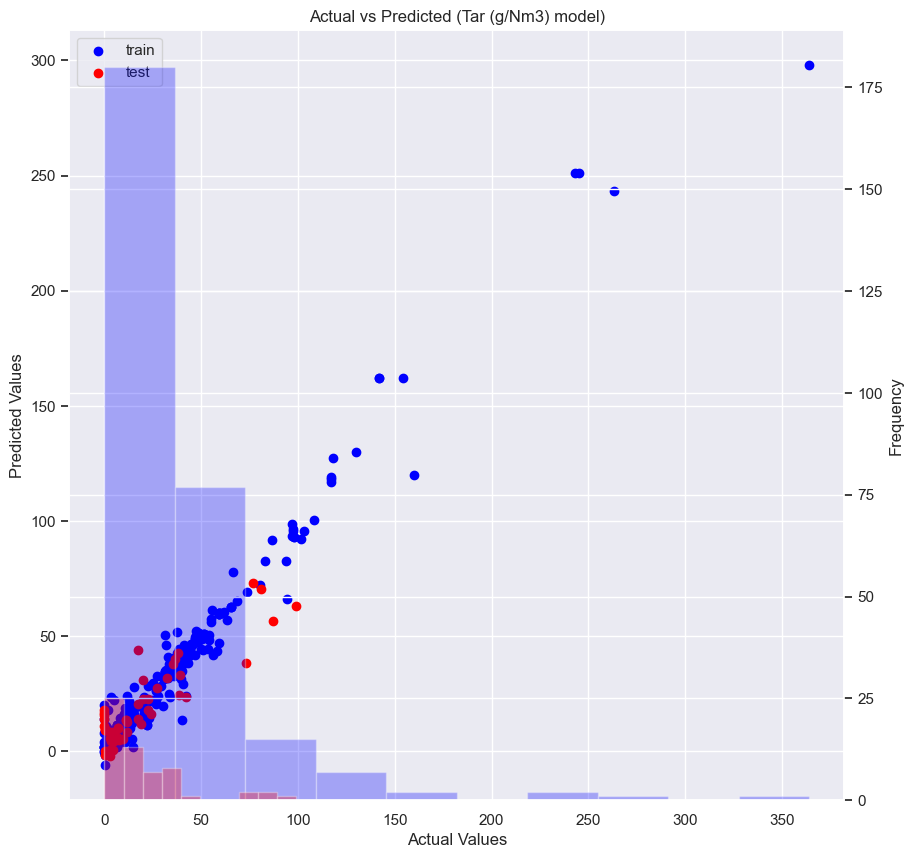

In [74]:
for model in ['H2 (% db)', 'CO2 (% db)', 'Tar (g/Nm3)']:
  fig, ax1 = plt.subplots(figsize=(10,10))
  ax1.scatter(Y_train_pretreated[model], Predict_train[model], color='blue', label='train')
  ax1.scatter(Y_test_pretreated[model], Predict_test[model], color='red', label='test')
  #ax1.plot([0,0], [1,1], 'r--', label='Ideal fit')
  ax1.set_xlabel('Actual Values')
  ax1.set_ylabel('Predicted Values')
  ax1.legend()

  ax2 = ax1.twinx()
  ax2.hist(Y_train_pretreated[model], bins=10, alpha=0.3, color='blue')
  ax2.hist(Y_test[model], bins=10, alpha=0.3, color='red')
  ax2.set_ylabel('Frequency')
  
  plt.title(f'Actual vs Predicted ({model} model)')
  plt.show()

ADA

In [75]:
#model configuration using the tuned hyperparameter
model_ADA_H2 = AdaBoostRegressor(**ADA_H2.best_params_)

model_ADA_CO2 = AdaBoostRegressor(**ADA_CO2.best_params_)

model_ADA_CO = AdaBoostRegressor(**ADA_CO.best_params_)

model_ADA_Tar = AdaBoostRegressor(**ADA_Tar.best_params_)

#FIt model_ADA with training data
model_ADA_H2.fit(X_train, Y_train_pretreated['H2 (% db)'])
model_ADA_CO2.fit(X_train, Y_train_pretreated['CO2 (% db)'])
model_ADA_CO.fit(X_train, Y_train_pretreated['CO (% db)'])
model_ADA_Tar.fit(X_train, Y_train_pretreated['Tar (g/Nm3)'])

#Predict and evaluate model_ADA performance
Predict_train = predict_evaluate(model_ADA_H2, model_ADA_CO2, model_ADA_CO, model_ADA_Tar, X_train, Y_train_pretreated)

Evaluation score of H2 (% db) model;
R2 score: 0.90
MSE: 21.38
-----------------------------
Evaluation score of CO2 (% db) model;
R2 score: 0.82
MSE: 7.56
-----------------------------
Evaluation score of CO (% db) model;
R2 score: 0.79
MSE: 17.84
-----------------------------
Evaluation score of Tar (g/Nm3) model;
R2 score: 0.86
MSE: 246.04
-----------------------------


In [76]:
Y_test_pretreated = Y_test.dropna(axis=0)
X_test_pretreated = X_test.loc[Y_test_pretreated.index]

#Normalize data into [0,1]
#for index, row in Y_test_pretreated.iterrows():
#    for columns in Y_test_pretreated.columns:
#        norm = (row[columns] - Y_test_pretreated[columns].min()) / (Y_test_pretreated[columns].max() - Y_test_pretreated[columns].min())
#        Y_test_pretreated.at[index, columns] = norm

Predict_test = predict_evaluate(model_ADA_H2, model_ADA_CO2, model_ADA_CO, model_ADA_Tar, X_test_pretreated, Y_test_pretreated)

Evaluation score of H2 (% db) model;
R2 score: 0.90
MSE: 29.20
-----------------------------
Evaluation score of CO2 (% db) model;
R2 score: 0.85
MSE: 7.83
-----------------------------
Evaluation score of CO (% db) model;
R2 score: 0.66
MSE: 23.64
-----------------------------
Evaluation score of Tar (g/Nm3) model;
R2 score: 0.29
MSE: 433.51
-----------------------------


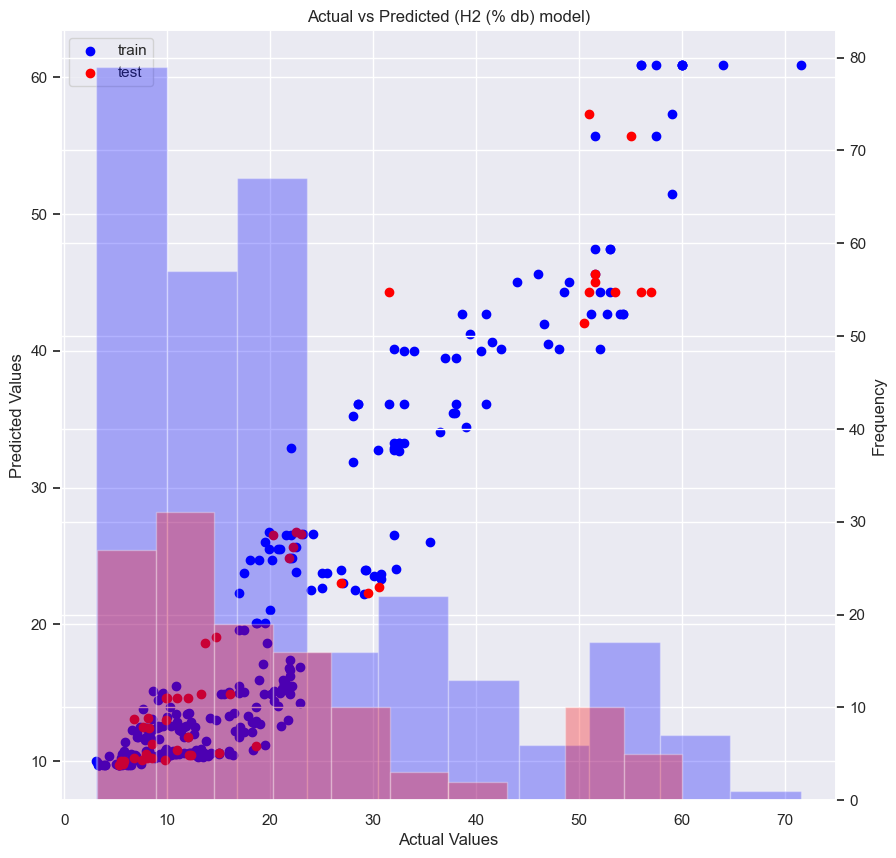

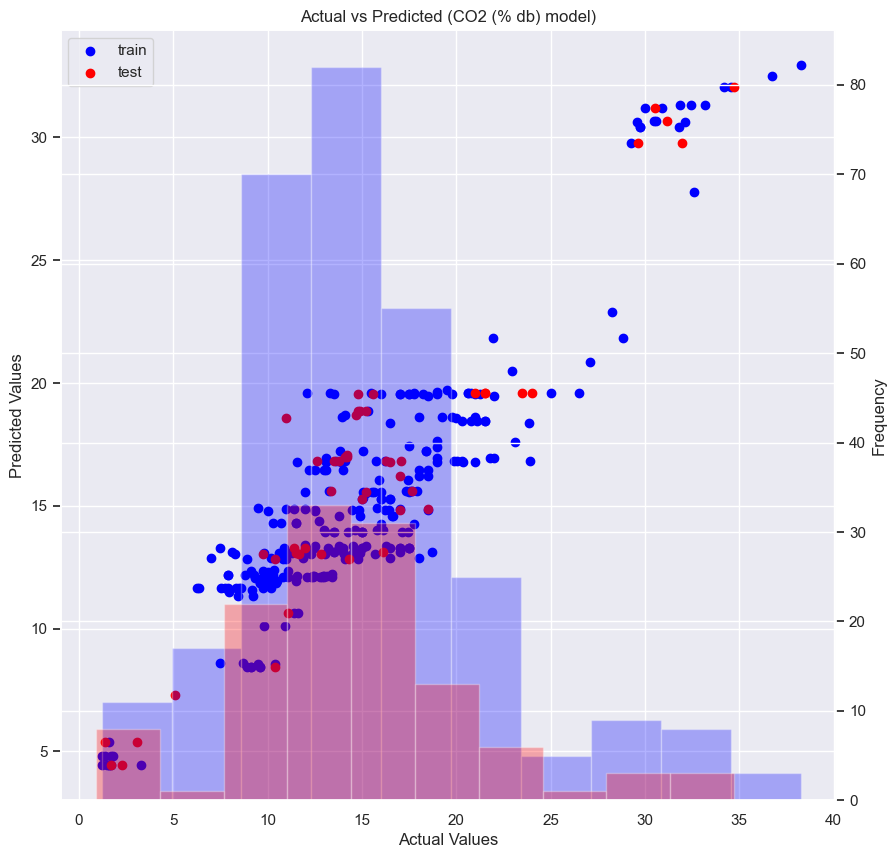

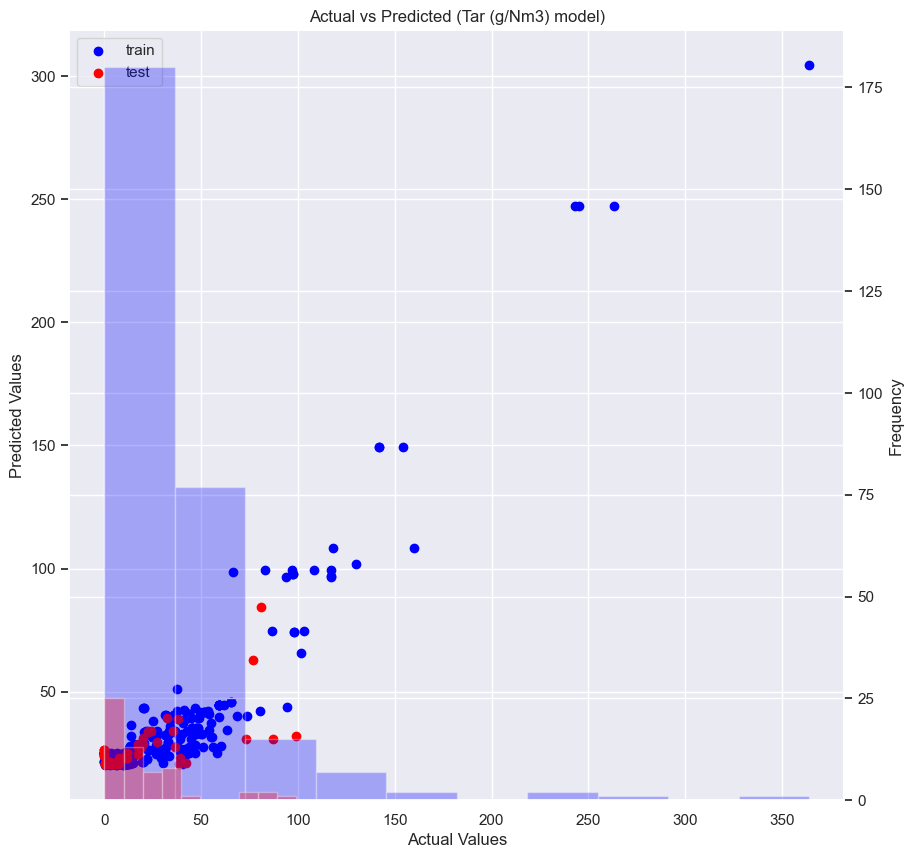

In [77]:
for model in ['H2 (% db)', 'CO2 (% db)', 'Tar (g/Nm3)']:
  fig, ax1 = plt.subplots(figsize=(10,10))
  ax1.scatter(Y_train_pretreated[model], Predict_train[model], color='blue', label='train')
  ax1.scatter(Y_test_pretreated[model], Predict_test[model], color='red', label='test')
  #ax1.plot([0,0], [1,1], 'r--', label='Ideal fit')
  ax1.set_xlabel('Actual Values')
  ax1.set_ylabel('Predicted Values')
  ax1.legend()

  ax2 = ax1.twinx()
  ax2.hist(Y_train_pretreated[model], bins=10, alpha=0.3, color='blue')
  ax2.hist(Y_test[model], bins=10, alpha=0.3, color='red')
  ax2.set_ylabel('Frequency')
  
  plt.title(f'Actual vs Predicted ({model} model)')
  plt.show()

SHAP Analysis

In [98]:
def SHAP(model_list, train, test):
    list=[]
    for i in range(len(model_list)):
        # Execute SHAP anlysis and get shap values
        shap_explainer = shap.TreeExplainer(model_list[i])
        df = pd.concat([train, test], axis=1)
        shap_values = shap_explainer.shap_values(df)
        
        #Plot of SHAP
        print('SHAP Analysis for ', str(model_list[i]))
        shap.summary_plot(shap_values, df, max_display=10)
        shap.summary_plot(shap_values, df, plot_type='bar', max_display=10)
        
        # Calculate mean absolute SHAP values for each feature
        feature_importance = np.abs(shap_values).mean(axis=0)

        # Get the indices of the 5 most important features
        top_features = np.argsort(feature_importance)[-3:][::-1]

        # Get feature names
        feature_names = X_train.columns

        list.append(top_features.tolist())
    
    return list

SHAP analysis of GBR

SHAP Analysis for  GradientBoostingRegressor(learning_rate=0.1255712973386197, max_depth=16,
                          max_features=0.2739086669407148, min_samples_split=16,
                          n_estimators=322, subsample=0.4722951899946878)


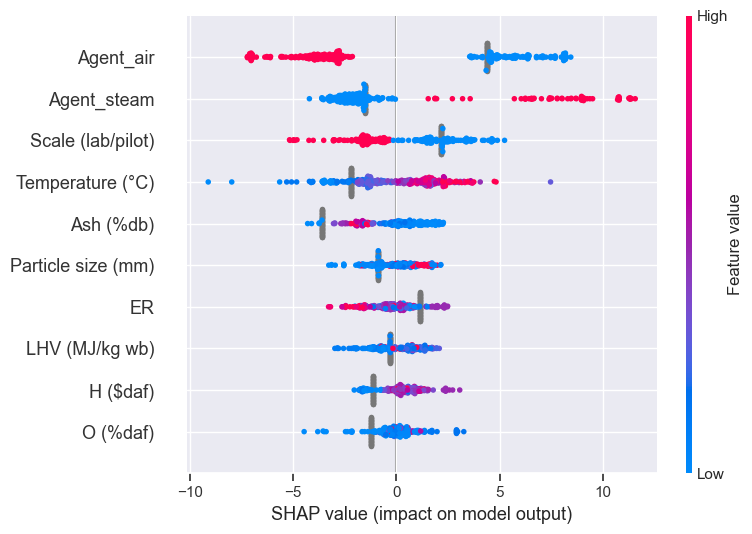

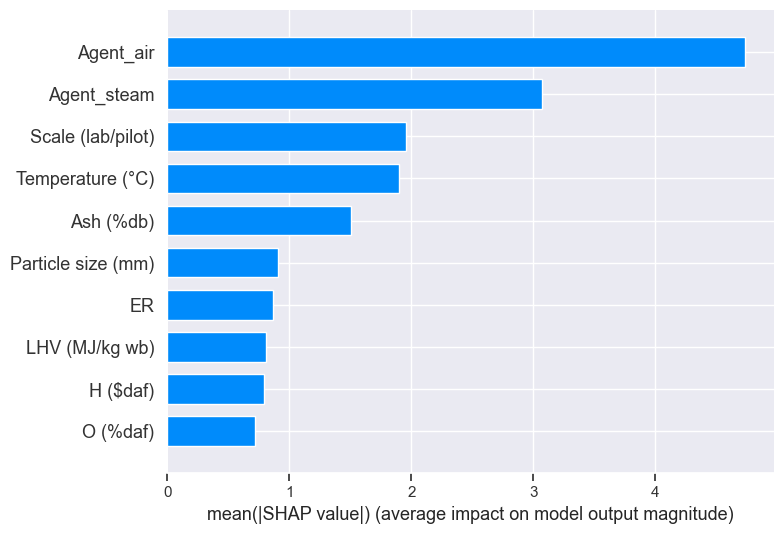

SHAP Analysis for  GradientBoostingRegressor(learning_rate=0.07071829316621223, max_depth=14,
                          max_features=0.12593196212441182, n_estimators=50,
                          subsample=0.7225305933646885)


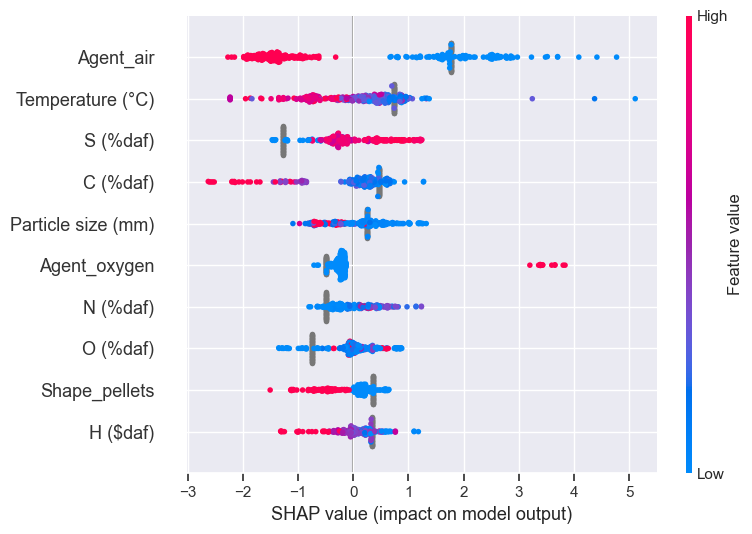

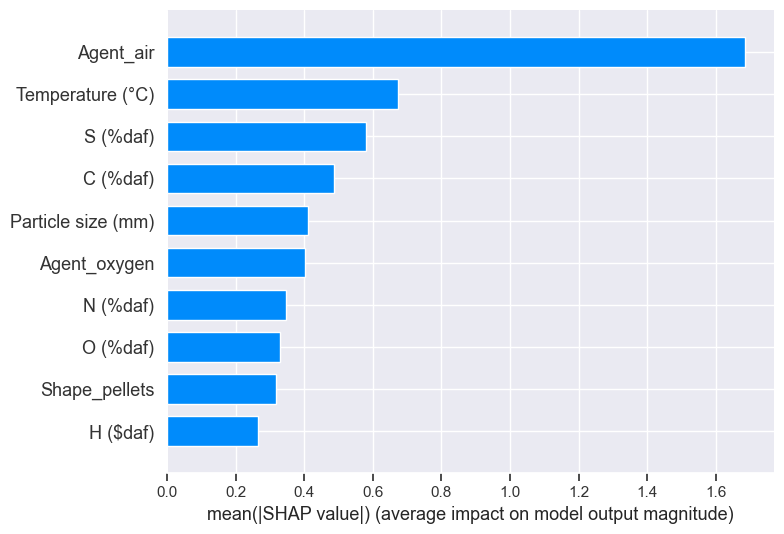

SHAP Analysis for  GradientBoostingRegressor(learning_rate=0.22202777607065113, max_depth=11,
                          max_features=0.46597688193211484, min_samples_leaf=10,
                          min_samples_split=15, n_estimators=125,
                          subsample=0.8923003398925902)


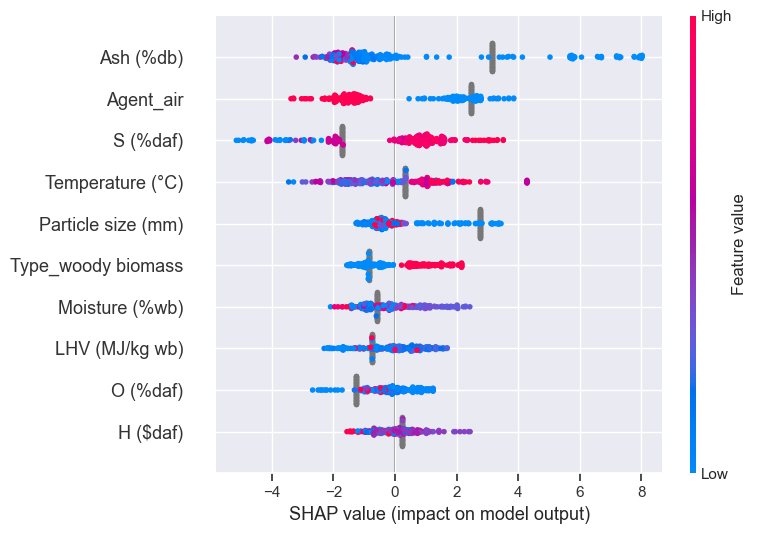

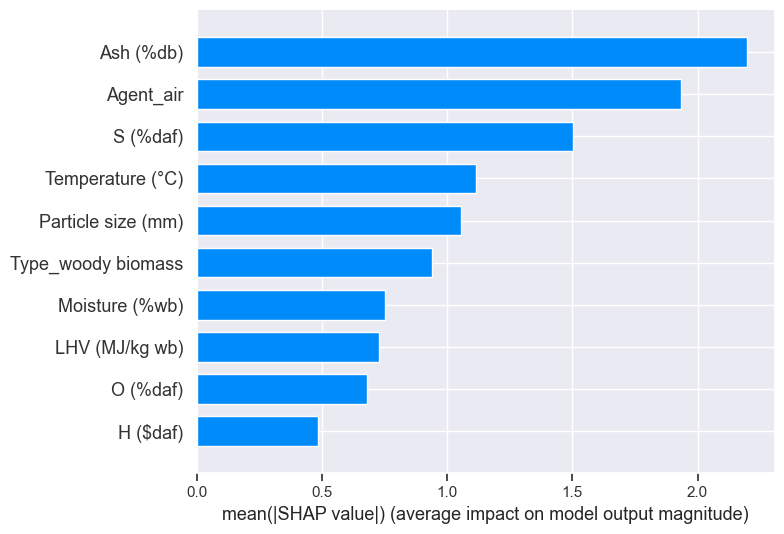

SHAP Analysis for  GradientBoostingRegressor(learning_rate=0.06262080732607031, max_depth=20,
                          max_features=0.12786434478489825, min_samples_leaf=19,
                          min_samples_split=20, n_estimators=500)


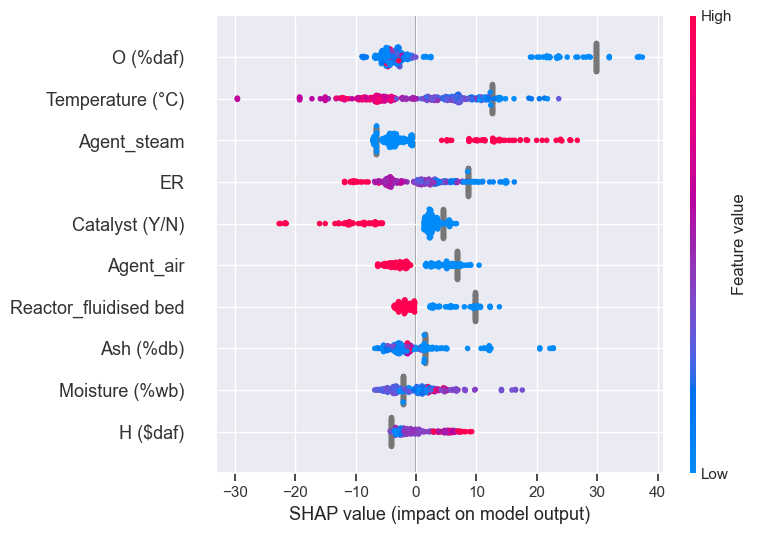

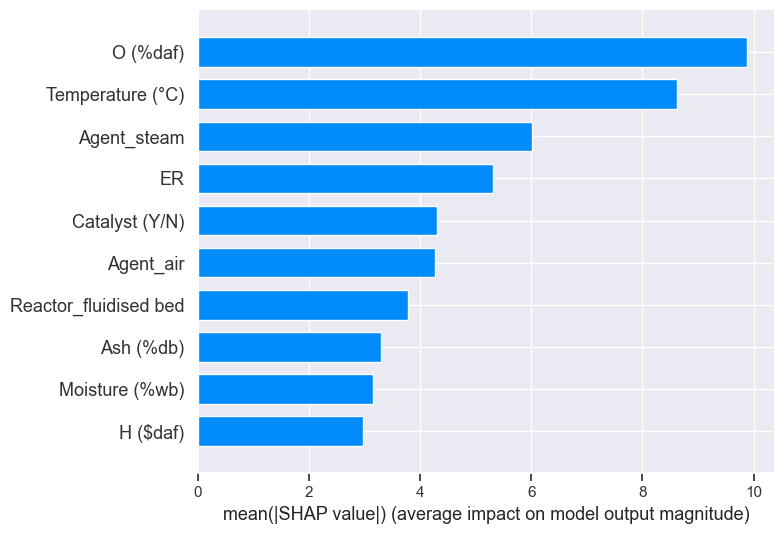

In [99]:
GBR_list = [model_GBR_H2, model_GBR_CO2, model_GBR_CO, model_GBR_Tar]
GBR_top_list = SHAP(GBR_list, X_train, X_test_pretreated)

Partial dependency plot

In [105]:
def PDP(model_list,X):           
    for i  in range(len(model_list)):
        for a in GBR_top_list[i]:
            for b in GBR_top_list[i]:
                if b == a:
                    continue
                else:
                    features = [a, b, (a, b)]
                    fig, ax = plt.subplots(figsize=(12, 6))
                    PartialDependenceDisplay.from_estimator(model_list[i], X, features, ax=ax)

[[24, 27, 13], [24, 9, 6], [7, 24, 6], [4, 9, 27]]


C:\Users\HP\AppData\Local\Temp\ipykernel_4908\471654237.py:9: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(figsize=(12, 6))


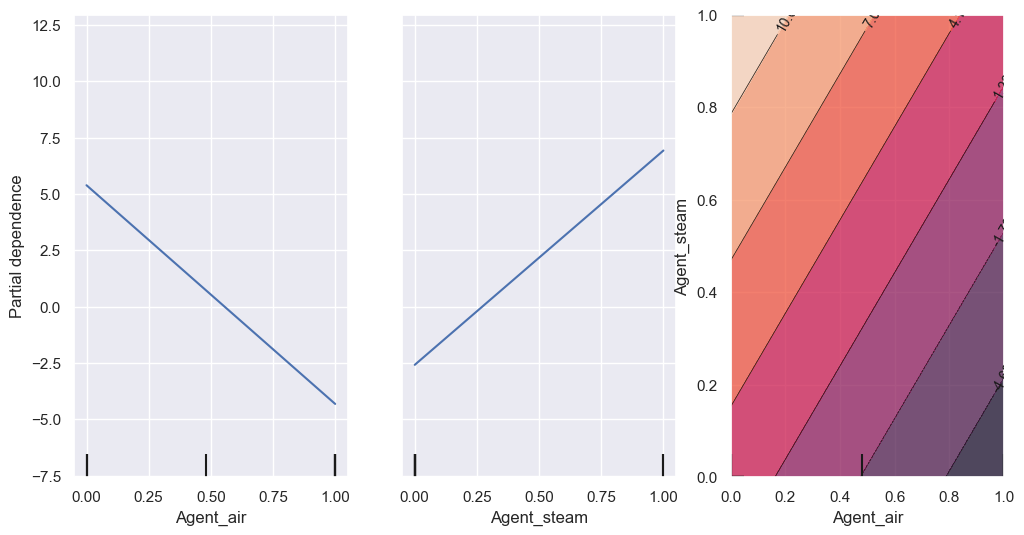

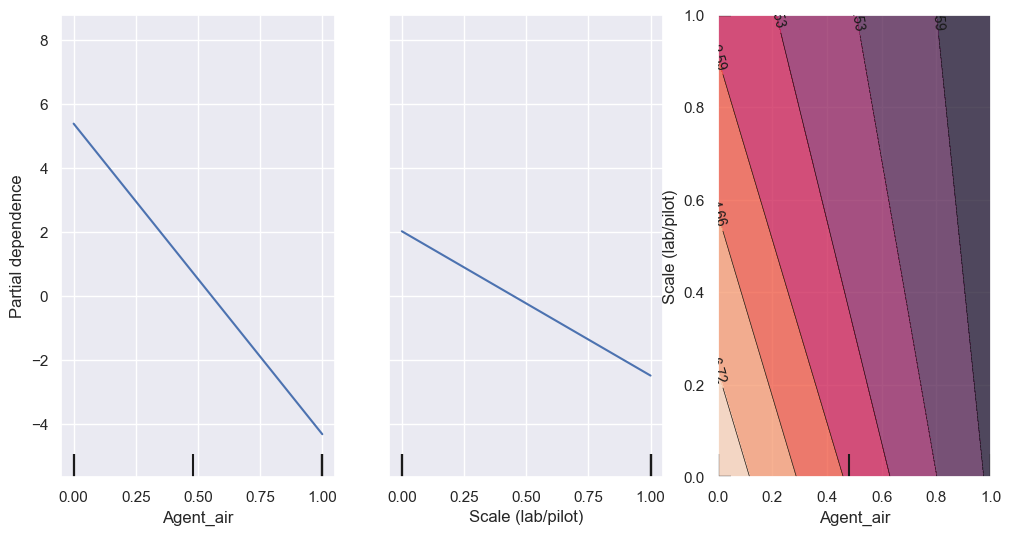

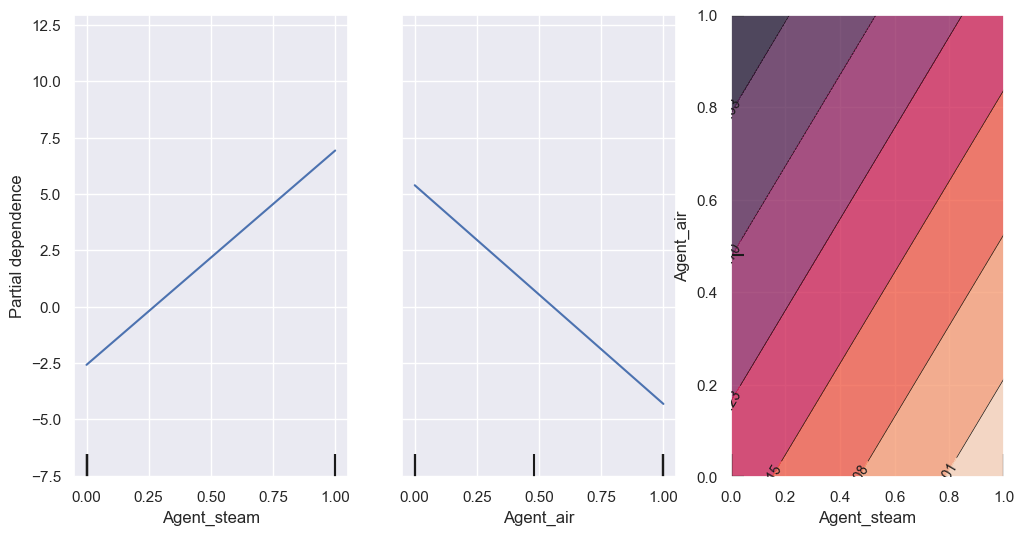

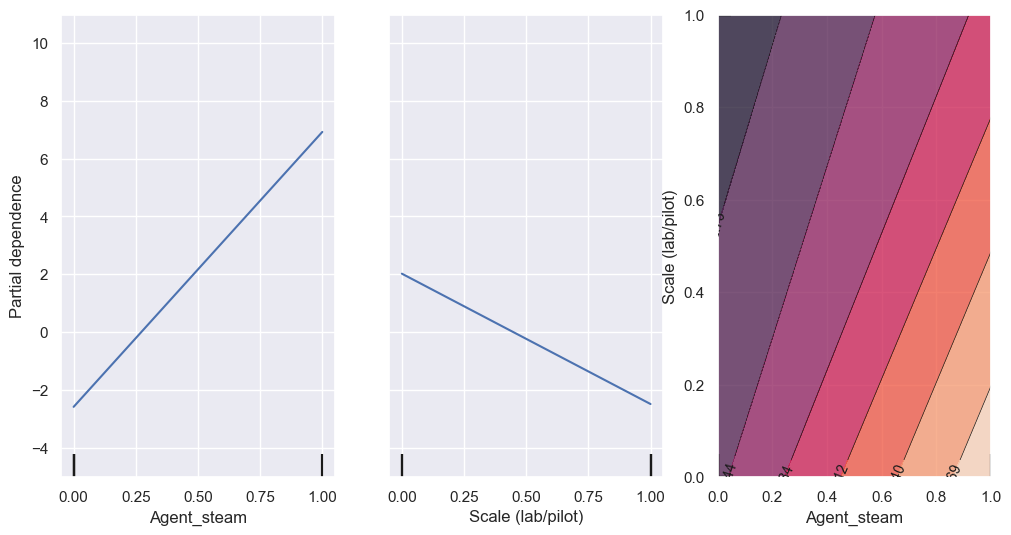

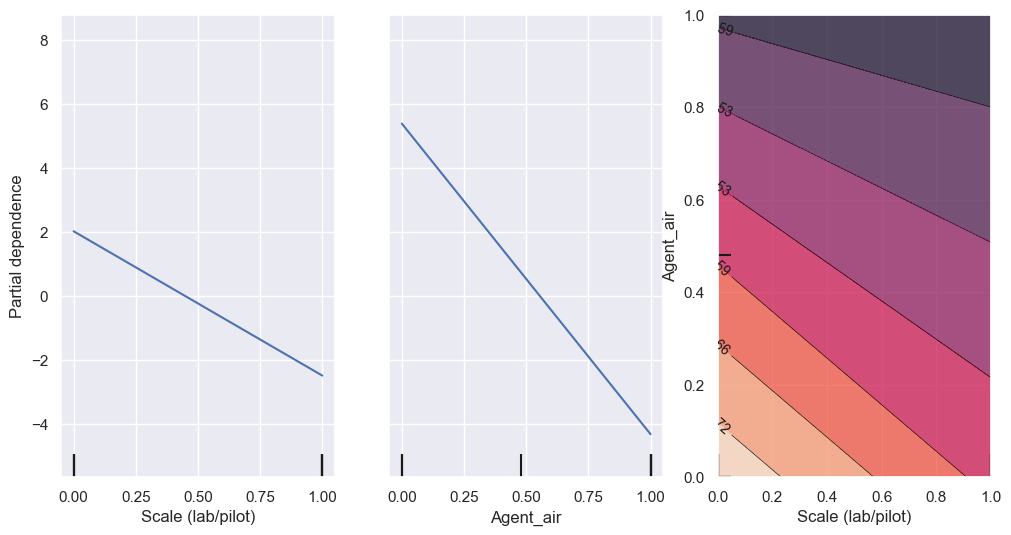

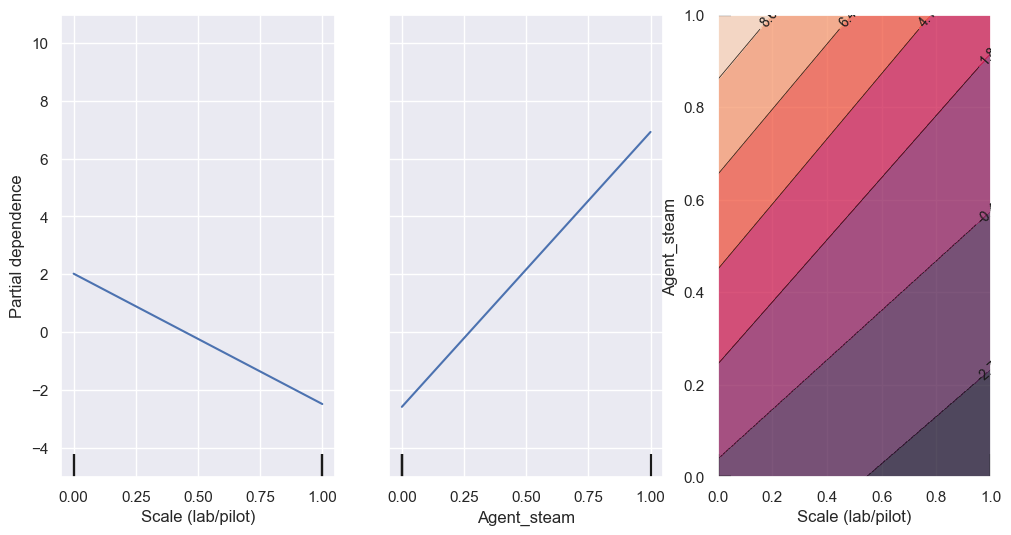

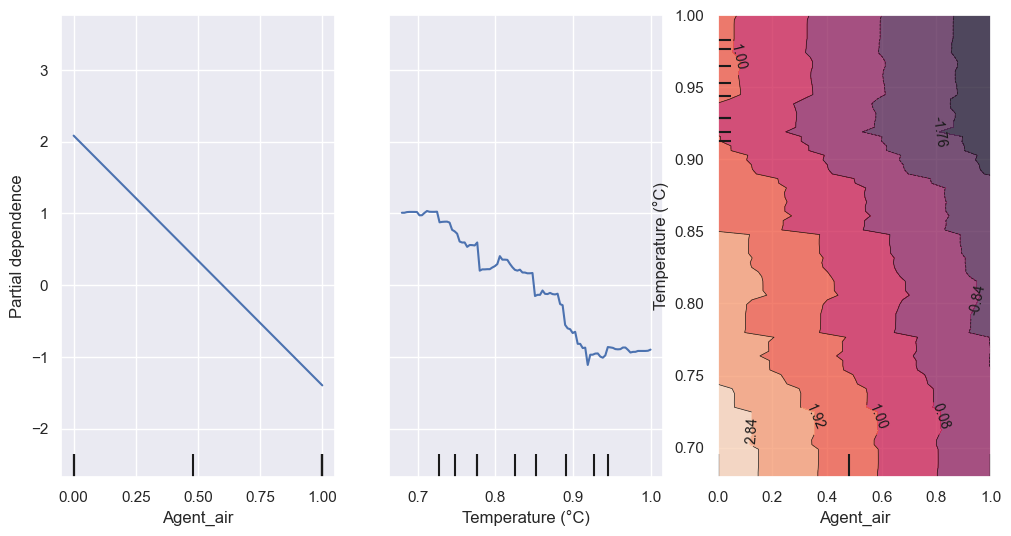

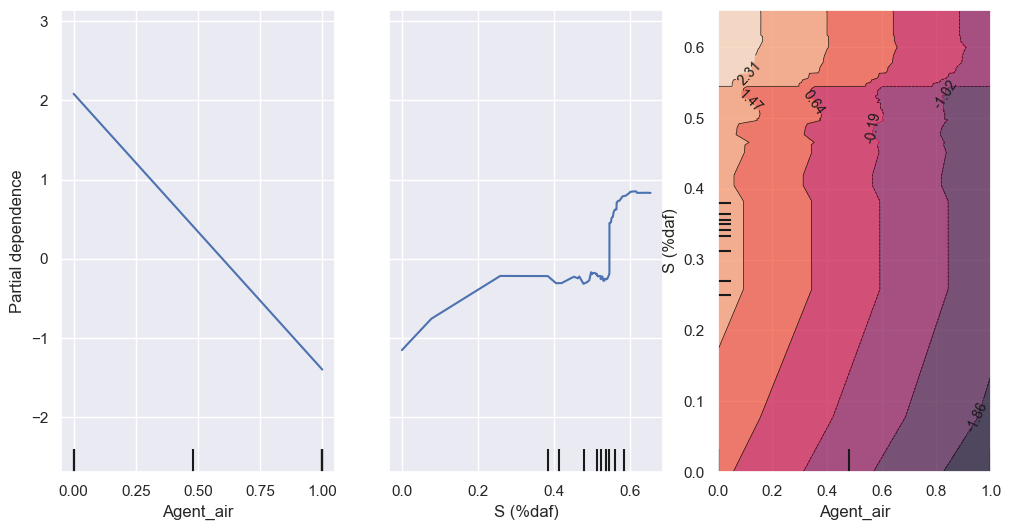

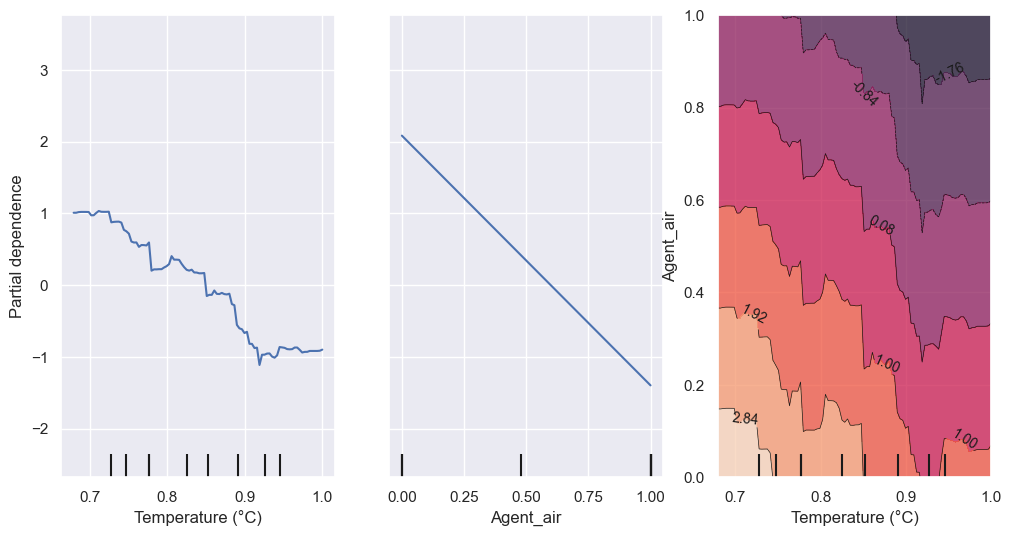

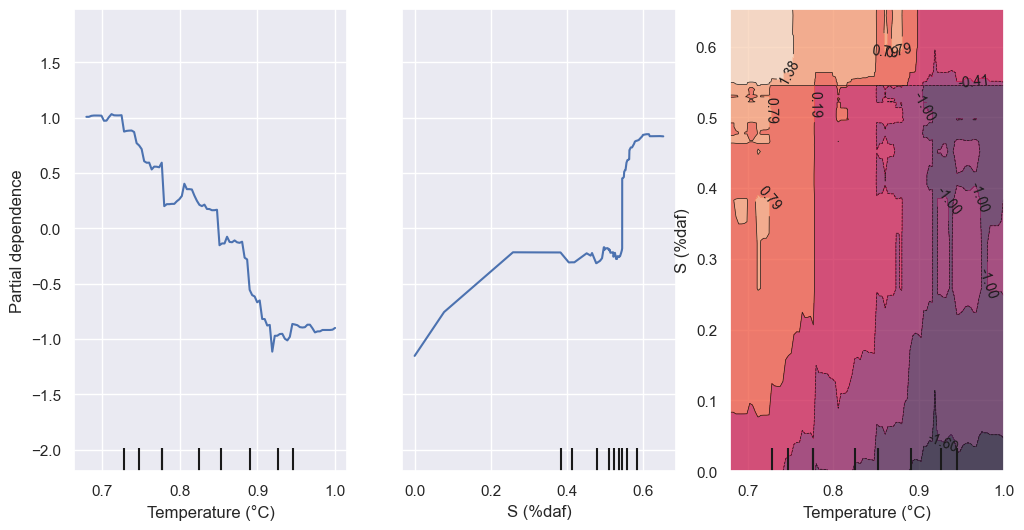

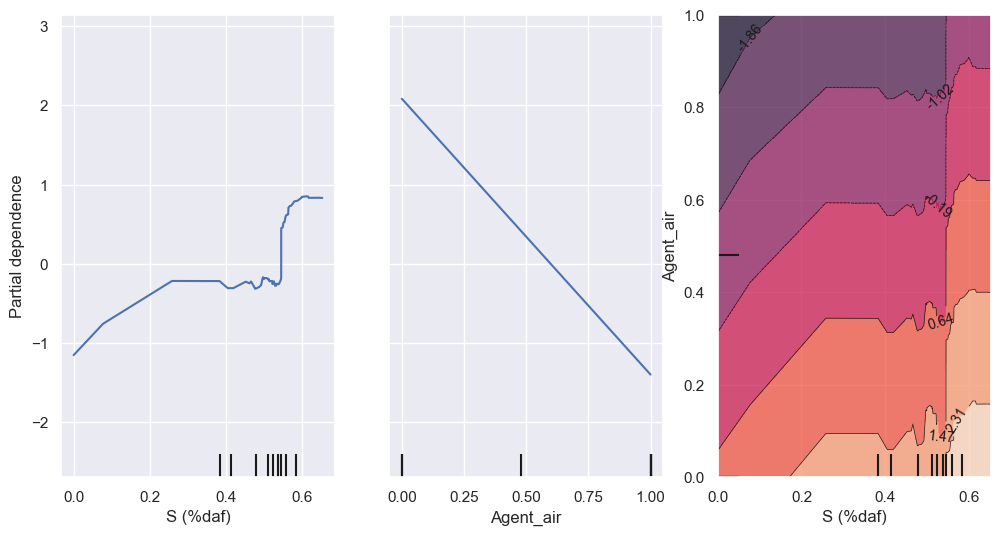

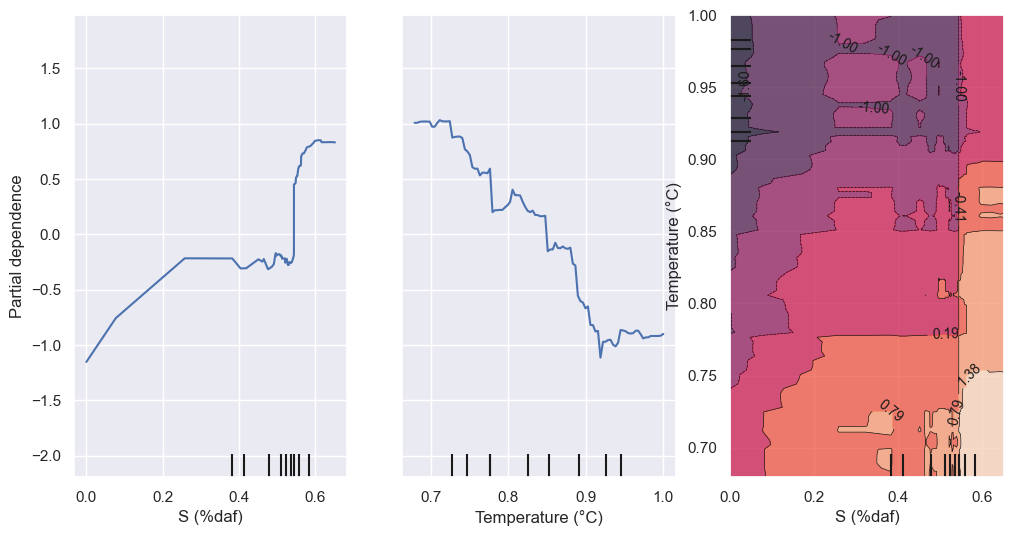

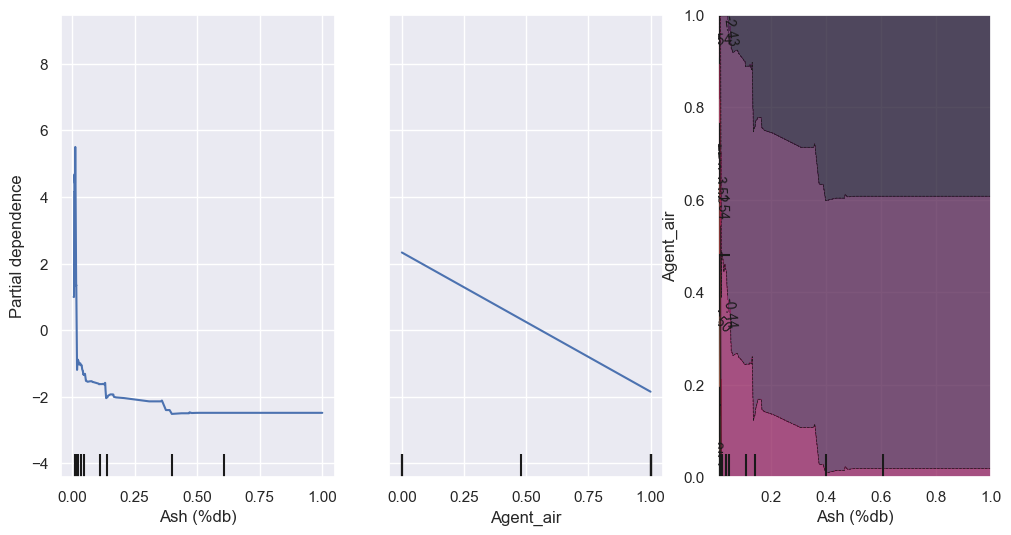

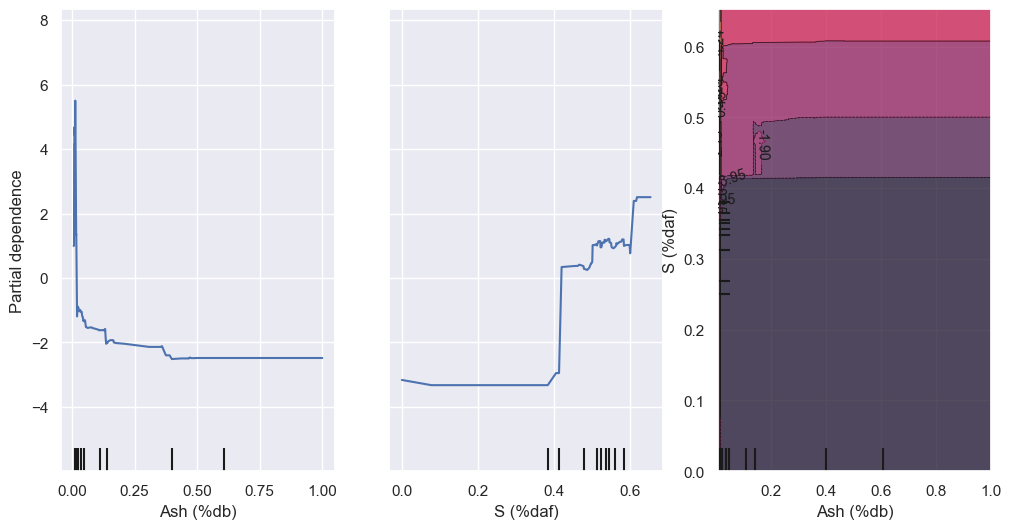

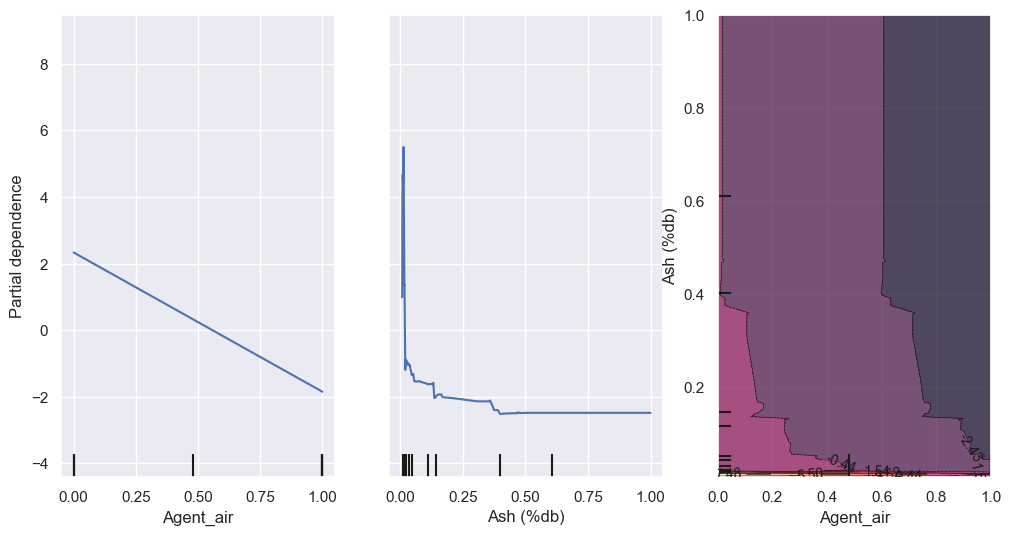

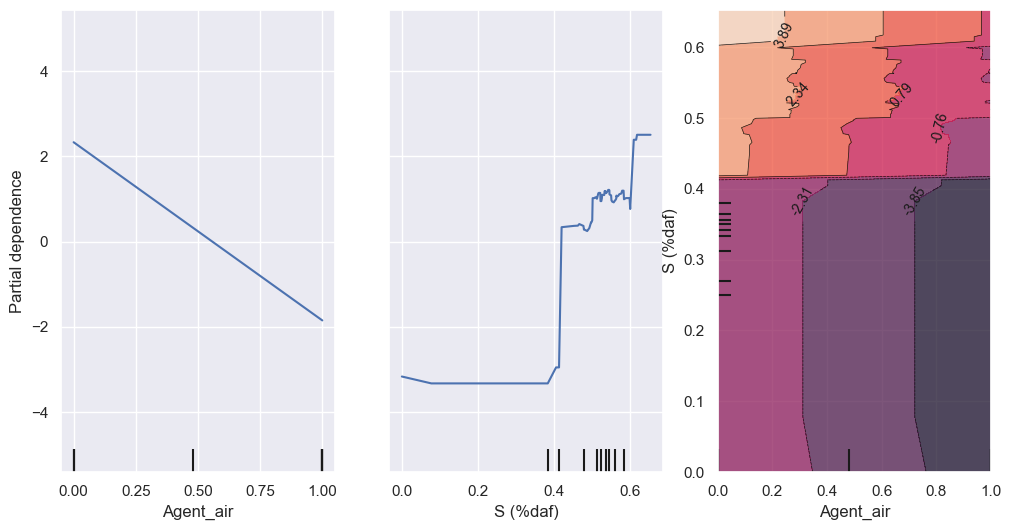

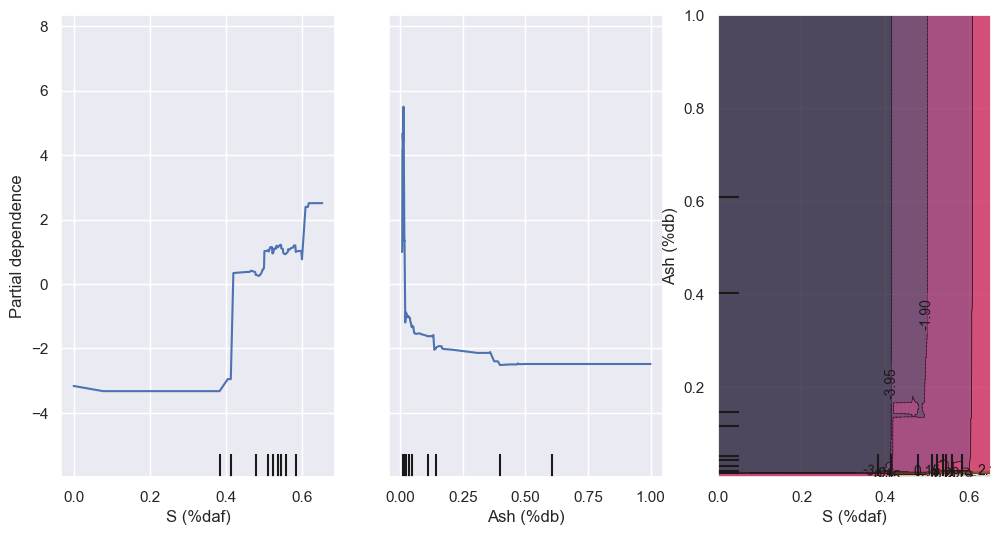

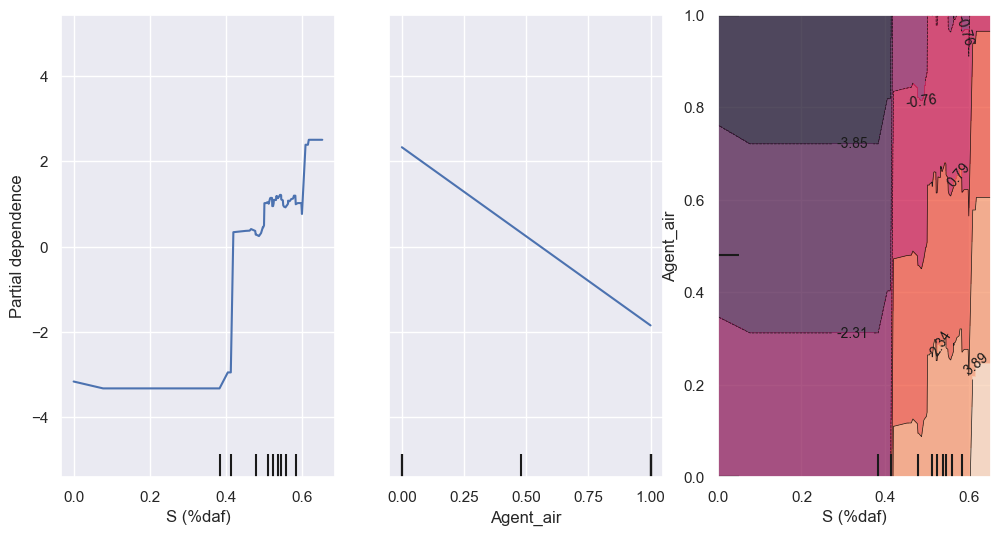

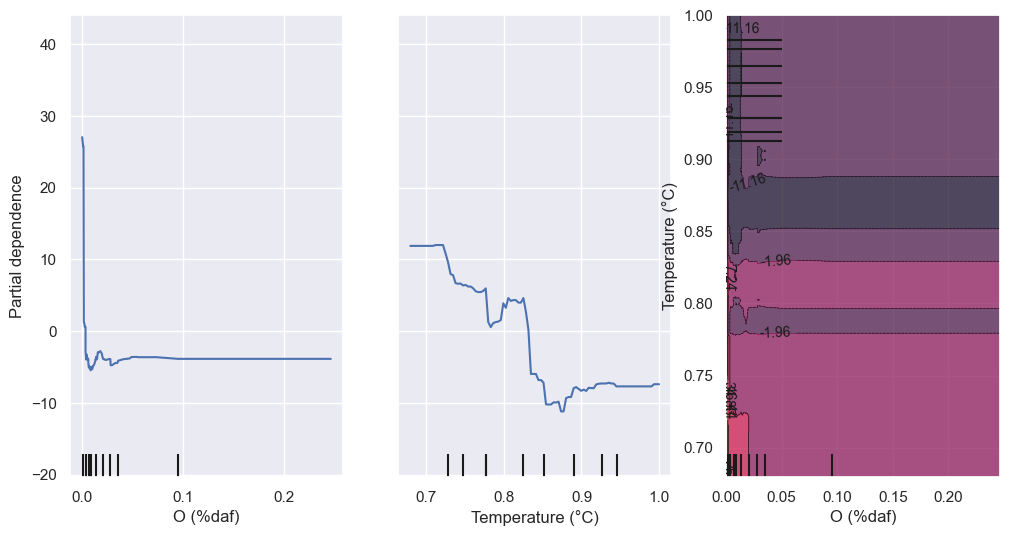

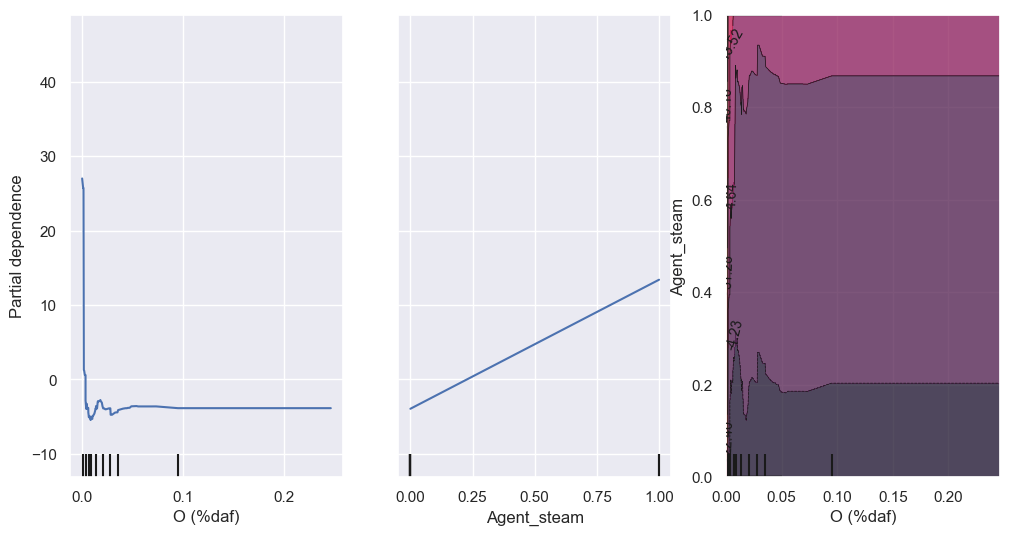

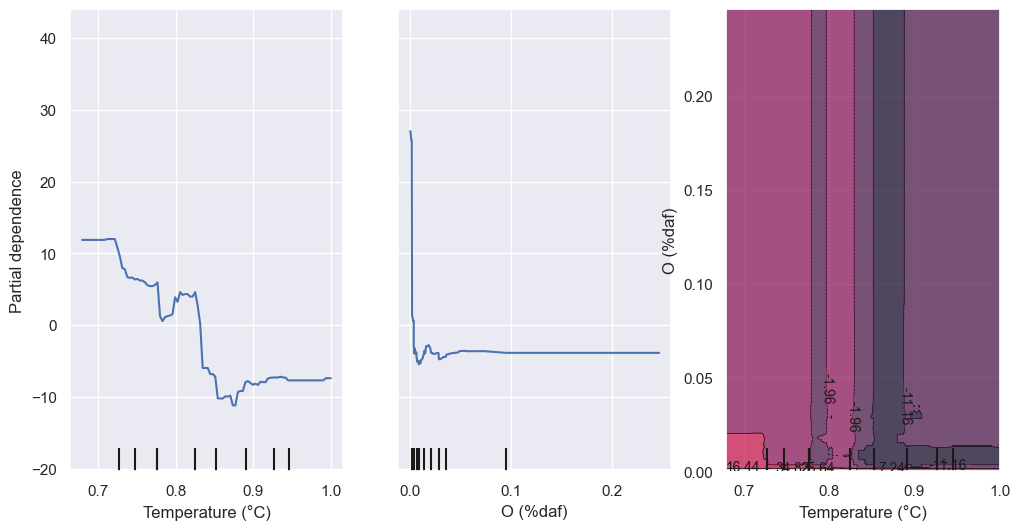

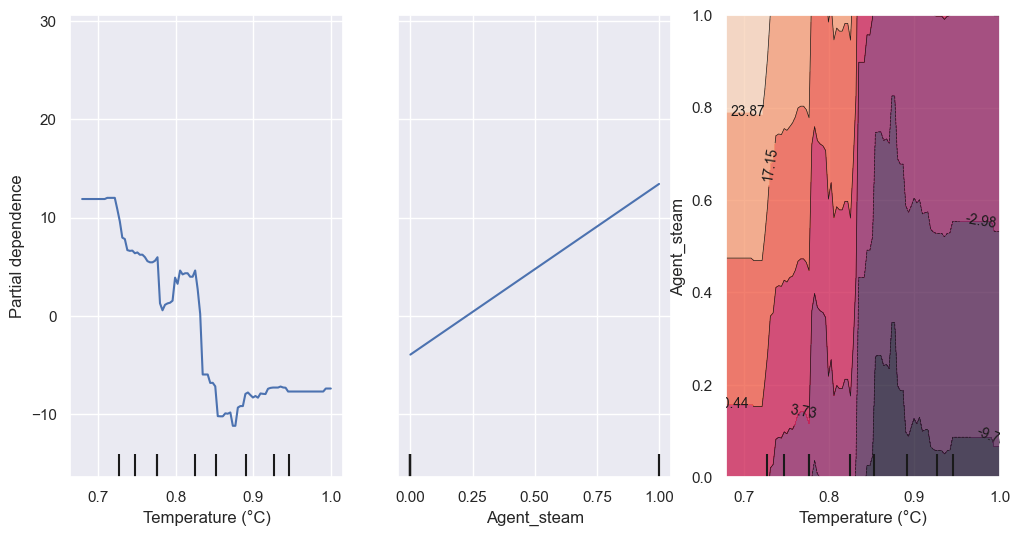

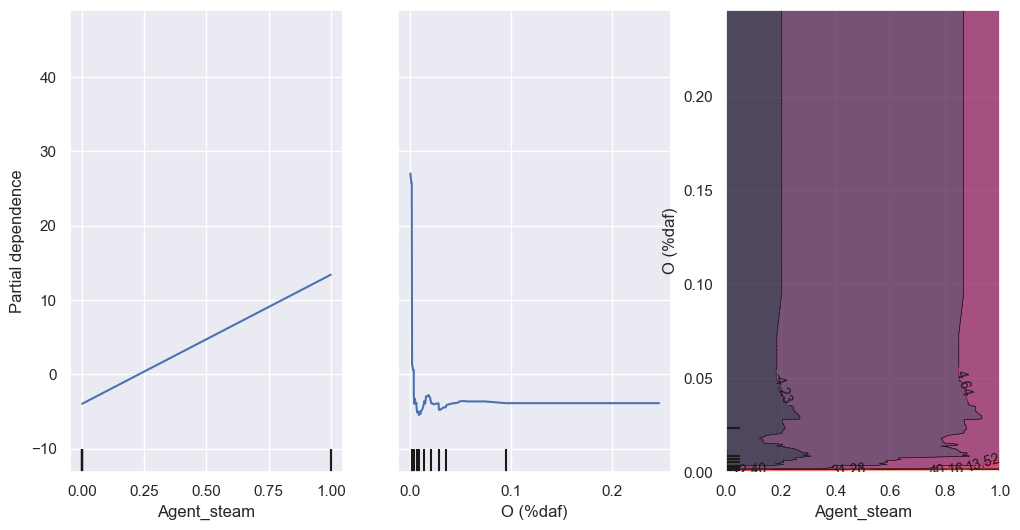

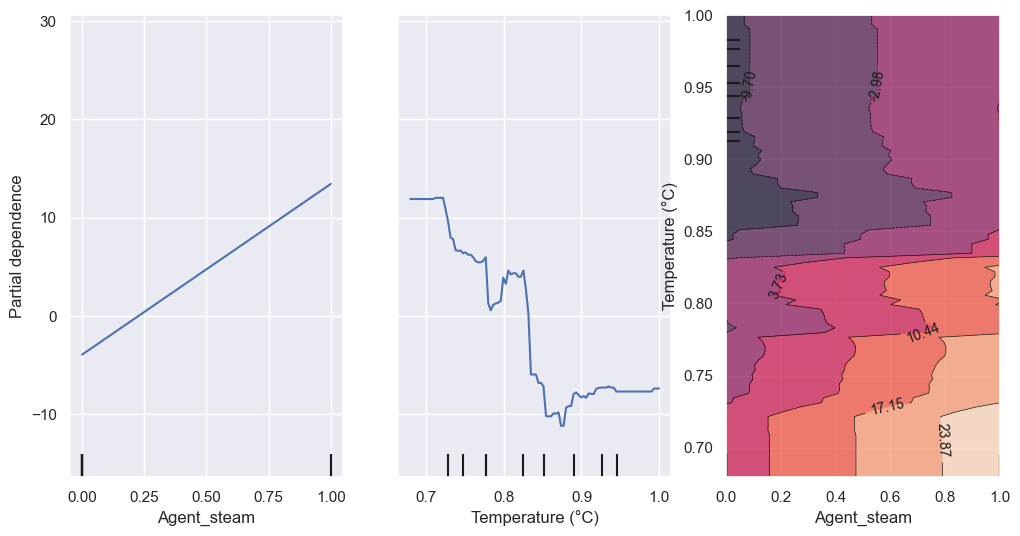

In [106]:
print(GBR_top_list)

PDP(GBR_list, X_train)